# Sección 5 — Métricas y Evaluación Gráfica Comparativa

## Propósito de este notebook

Este notebook realiza la
**evaluación ciega** de los cinco modelos exclusivamente sobre el conjunto de
**Test**, que no fue utilizado en ninguna fase de ajuste de hiperparámetros ni
de entrenamiento.

Este protocolo de evaluación garantiza que los resultados reportados son
una estimación honesta del rendimiento que se puede esperar en producción,
sin filtración de información del conjunto de evaluación hacia el modelo.

### Entregables de este notebook

| Artefacto | Descripción |
|-----------|-------------|
| Matriz de confusión normalizada | Por modelo — permite identificar patrones de error entre clases |
| Curva ROC (macro-avg) | Por modelo — mide la capacidad discriminativa global |
| Curva Precision-Recall (macro-avg) | Por modelo — más informativa que ROC en datasets desbalanceados |
| Tabla comparativa consolidada | Los 5 modelos bajo las mismas métricas, ordenados por F1 |

### Entradas requeridas
- `artifacts/preprocessing_config.json`
- `artifacts/X_test.npy`, `artifacts/y_test.npy`
- `artifacts/test_texts.pkl`
- `checkpoints/*.pt` y `checkpoints/tfidf_xgb.pkl`


In [2]:
from google.colab import drive
import os

# 1. Montamos el Drive
drive.mount('/content/drive')

# 2. Nos paramos en la RAÍZ (PLN) para que las rutas ../artifacts funcionen
%cd /content/drive/MyDrive/PLN

# 3. Verificación
print("Entorno listo. Carpetas detectadas:")
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/PLN
Entorno listo. Carpetas detectadas:
artifacts  checkpoints	data  env  figures  notebooks  requirements.txt  Resume


---
## 5.1 Configuración del entorno

Se cargan las dependencias, los artefactos generados por el Notebook 2
y los checkpoints guardados por el Notebook 4. Todos los modelos se
reconstruyen en modo evaluación (`eval()`) antes de cualquier inferencia.


In [3]:
import json, pickle, warnings, logging
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
    roc_curve, auc, precision_recall_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)
Path("figures").mkdir(exist_ok=True)

# ── Verificar que el entrenamiento se completó ────────────────────────────────
if not Path("artifacts/training_done.flag").exists():
    raise RuntimeError("Ejecuta primero el Notebook 4 para entrenar los modelos.")

# ── Configuración compartida ──────────────────────────────────────────────────
with open("artifacts/preprocessing_config.json") as f:
    cfg = json.load(f)

VOCAB_SIZE      = cfg["vocab_size"]
NUM_CLASSES     = cfg["num_classes"]
SEQUENCE_LENGTH = cfg["sequence_length"]
EMBEDDING_DIM   = cfg["embedding_dim"]
CLASS_NAMES     = cfg["class_names"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info("Device: %s | Clases: %d", DEVICE, NUM_CLASSES)

# ── Arrays de test ────────────────────────────────────────────────────────────
X_test = np.load("artifacts/X_test.npy")
y_test = np.load("artifacts/y_test.npy")

with open("artifacts/test_texts.pkl", "rb") as f:
    text_data = pickle.load(f)

test_texts = text_data["test_texts"]
clean_test = text_data["clean_test"]

print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}  —  clases únicas: {np.unique(y_test)}")


X_test : (373, 400)
y_test : (373,)  —  clases únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


## Reconstrucción de modelos e inferencia ciega sobre el conjunto de Test

### ¿Por qué reconstruir las clases en este notebook?

PyTorch guarda los checkpoints como **diccionarios de estado** (`state_dict`): solo
los pesos del modelo, no su arquitectura. Para deserializar un archivo `.pt` es
necesario instanciar primero la clase Python correspondiente con exactamente los
mismos hiperparámetros usados durante el entrenamiento, y luego cargar los pesos
con `load_state_dict()`. Las clases se redefinen aquí para que este notebook sea
**completamente autónomo** y ejecutable sin depender del estado de memoria del
Notebook 4.

El clasificador TF-IDF + XGBoost se deserializa desde un archivo `.pkl` mediante
`pickle.load()`, que sí serializa tanto los pesos como la estructura del modelo
(incluido el vectorizador TF-IDF ajustado).

### Principio de evaluación ciega

El conjunto de **Test** fue separado **antes** de cualquier decisión de
preprocesamiento, selección de hiperparámetros o entrenamiento. Esto es crítico:

- El vocabulario se construyó solo con textos de **Train**.
- Los hiperparámetros se ajustaron monitoreando métricas de **Validación**.
- El Test nunca fue visto por ningún modelo durante ninguna fase del pipeline.

Esta separación garantiza que los resultados reportados en este notebook son una
**estimación no sesgada del error de generalización**, equivalente al rendimiento
que se esperaría al desplegar el modelo sobre CVs nuevos en un entorno real.
Usar el Test para cualquier decisión intermedia invalidaría esta garantía.

---
## 5.2 Reconstrucción de los modelos

Cada arquitectura se reinstancia con los mismos hiperparámetros usados
en el entrenamiento y se carga el estado del mejor checkpoint.
Esto garantiza que la evaluación usa exactamente los pesos que lograron
el menor error de validación, no los del último epoch.


In [4]:
# ── Definición de clases (replica exacta de los Notebooks 3 y 4) ─────────────

@dataclass
class BiLSTMConfig:
    vocab_size: int; num_classes: int
    embedding_dim: int = 100;  lstm_units: int = 128;  num_lstm_layers: int = 2
    dropout_rate: float = 0.3; sequence_length: int = 100
    learning_rate: float = 0.001; batch_size: int = 64; epochs: int = 20
    freeze_embeddings: bool = False
    pretrained_weights: Optional[np.ndarray] = field(default=None, repr=False)

class BiLSTMClassifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        w = cfg.pretrained_weights
        if w is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(w, dtype=torch.float32), freeze=cfg.freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(cfg.vocab_size, cfg.embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(cfg.embedding_dim, cfg.lstm_units, cfg.num_lstm_layers,
                            batch_first=True, bidirectional=True,
                            dropout=cfg.dropout_rate if cfg.num_lstm_layers > 1 else 0.0)
        self.dropout = nn.Dropout(cfg.dropout_rate)
        self.fc      = nn.Linear(cfg.lstm_units * 2, cfg.num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(emb)
        return self.fc(self.dropout(torch.cat([h[-2], h[-1]], dim=1)))

class CNN1DClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=100, num_filters=128,
                 kernel_sizes=(3,4,5), dropout_rate=0.4, pretrained_weights=None,
                 freeze_embeddings=False):
        super().__init__()
        if pretrained_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(pretrained_weights, dtype=torch.float32),
                freeze=freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs   = nn.ModuleList([nn.Conv2d(1, num_filters, (k, embedding_dim)) for k in kernel_sizes])
        self.dropout = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def _conv_pool(self, conv, x):
        return torch.max(torch.relu(conv(x)).squeeze(3), dim=2).values

    def forward(self, x):
        emb = self.embedding(x).unsqueeze(1)
        return self.fc(self.dropout(torch.cat([self._conv_pool(c, emb) for c in self.convs], dim=1)))

class FastTextMeanClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=100, dropout_rate=0.3,
                 pretrained_weights=None, freeze_embeddings=False):
        super().__init__()
        if pretrained_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(pretrained_weights, dtype=torch.float32),
                freeze=freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        mask     = (x != 0).float().unsqueeze(2)
        emb      = self.embedding(x) * mask
        mean_emb = emb.sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(self.dropout(mean_emb))

class TransformerClassifier:
    CHECKPOINTS = {"distilbert": "distilbert-base-uncased", "roberta": "roberta-base"}

    def __init__(self, num_classes, model_key="distilbert", max_length=128, device=None):
        self.num_classes = num_classes
        self.max_length  = max_length
        self.device      = device or torch.device("cpu")
        checkpoint       = self.CHECKPOINTS.get(model_key, model_key)
        self.tokenizer   = AutoTokenizer.from_pretrained(checkpoint)
        self.model       = AutoModelForSequenceClassification.from_pretrained(
            checkpoint, num_labels=num_classes, ignore_mismatched_sizes=True
        ).to(self.device)

    def tokenize(self, texts):
        return self.tokenizer(texts, max_length=self.max_length,
                              padding="max_length", truncation=True, return_tensors="pt")
    def eval_mode(self): self.model.eval()

    def forward(self, batch):
        batch = {k: v.to(self.device) for k, v in batch.items()}
        return self.model(**batch).logits

print("INFO | Clases de modelos definidas.")


INFO | Clases de modelos definidas.


In [6]:
# ── Re-definición de clases (copia exacta del Notebook 3) ──────────────────
from dataclasses import dataclass, field
from typing import Optional

# --- TransformerClassifier ---
from transformers import AutoModelForSequenceClassification, AutoTokenizer

class TransformerClassifier:
    CHECKPOINTS = {"distilbert": "distilbert-base-uncased", "roberta": "roberta-base"}

    def __init__(self, num_classes, model_key="distilbert", max_length=128, device=None):
        self.num_classes = num_classes
        self.max_length  = max_length
        self.device      = device or torch.device("cpu")
        checkpoint       = self.CHECKPOINTS.get(model_key, model_key)
        logger.info("Cargando checkpoint: %s", checkpoint)
        self.tokenizer = AutoTokenizer.from_pretrained(checkpoint)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            checkpoint, num_labels=num_classes, ignore_mismatched_sizes=True
        ).to(self.device)

    def tokenize(self, texts):
        return self.tokenizer(texts, max_length=self.max_length,
                              padding="max_length", truncation=True, return_tensors="pt")

    def parameters(self):  return self.model.parameters()
    def train_mode(self):  self.model.train()
    def eval_mode(self):   self.model.eval()

    def forward(self, batch):
        batch = {k: v.to(self.device) for k, v in batch.items()}
        return self.model(**batch).logits

# --- BiLSTM ---
@dataclass
class BiLSTMConfig:
    vocab_size: int;  num_classes: int
    embedding_dim: int = 100;  lstm_units: int = 128;  num_lstm_layers: int = 2
    dropout_rate: float = 0.3; sequence_length: int = 100
    learning_rate: float = 0.001; batch_size: int = 64; epochs: int = 20
    freeze_embeddings: bool = False
    pretrained_weights: Optional[np.ndarray] = field(default=None, repr=False)

class BiLSTMClassifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        w = cfg.pretrained_weights
        if w is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(w, dtype=torch.float32), freeze=cfg.freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(cfg.vocab_size, cfg.embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(cfg.embedding_dim, cfg.lstm_units, cfg.num_lstm_layers,
                            batch_first=True, bidirectional=True,
                            dropout=cfg.dropout_rate if cfg.num_lstm_layers > 1 else 0.0)
        self.dropout = nn.Dropout(cfg.dropout_rate)
        self.fc      = nn.Linear(cfg.lstm_units * 2, cfg.num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(emb)
        rep = self.dropout(torch.cat([h[-2], h[-1]], dim=1))
        return self.fc(rep)

# --- CNN-1D ---
class CNN1DClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=100, num_filters=128,
                 kernel_sizes=(3,4,5), dropout_rate=0.4, pretrained_weights=None,
                 freeze_embeddings=False):
        super().__init__()
        if pretrained_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(pretrained_weights, dtype=torch.float32),
                freeze=freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs   = nn.ModuleList([nn.Conv2d(1, num_filters, (k, embedding_dim)) for k in kernel_sizes])
        self.dropout = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def _conv_pool(self, conv, x):
        return torch.max(torch.relu(conv(x)).squeeze(3), dim=2).values

    def forward(self, x):
        emb = self.embedding(x).unsqueeze(1)
        return self.fc(self.dropout(torch.cat([self._conv_pool(c, emb) for c in self.convs], dim=1)))

# --- TF-IDF + XGBoost ---
from sklearn.feature_extraction.text import TfidfVectorizer
import xgboost as xgb

class TFIDFXGBoostClassifier:
    def __init__(self, max_features=30_000, ngram_range=(1,2), xgb_params=None):
        self.vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range,
                                          sublinear_tf=True, strip_accents="unicode",
                                          token_pattern=r"\b[a-zA-Z]{2,}\b")
        p = dict(n_estimators=500, max_depth=6, learning_rate=0.1, subsample=0.8,
                 colsample_bytree=0.8, eval_metric="mlogloss", tree_method="hist",
                 random_state=42, n_jobs=-1)
        if xgb_params: p.update(xgb_params)
        self.model = xgb.XGBClassifier(**p); self._fitted = False

    def fit(self, texts, y, eval_texts=None, eval_y=None):
        X = self.vectorizer.fit_transform(texts)
        ev = [(self.vectorizer.transform(eval_texts), eval_y)] if eval_texts is not None else None
        self.model.fit(X, y, eval_set=ev, verbose=False); self._fitted = True

    def predict(self, texts):        return self.model.predict(self.vectorizer.transform(texts))
    def predict_proba(self, texts):  return self.model.predict_proba(self.vectorizer.transform(texts))

# --- FastText Mean ---
class FastTextMeanClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=100, dropout_rate=0.3,
                 pretrained_weights=None, freeze_embeddings=False):
        super().__init__()
        if pretrained_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(pretrained_weights, dtype=torch.float32),
                freeze=freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        mask     = (x != 0).float().unsqueeze(2)
        emb      = self.embedding(x) * mask
        mean_emb = emb.sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(self.dropout(mean_emb))

print("INFO | Clases de modelos definidas.")

INFO | Clases de modelos definidas.


In [7]:
# ── Cargar embeddings y reconstruir modelos ───────────────────────────────────
w2v_matrix = np.load("artifacts/w2v_matrix.npy")
ft_matrix  = np.load("artifacts/ft_matrix.npy")

# BiLSTM
bilstm_cfg = BiLSTMConfig(
    vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM, lstm_units=128, num_lstm_layers=2,
    dropout_rate=0.3, pretrained_weights=w2v_matrix,
)
bilstm = BiLSTMClassifier(bilstm_cfg)
bilstm.load_state_dict(torch.load("checkpoints/bilstm_best.pt", map_location="cpu"))
bilstm = bilstm.to(DEVICE).eval()

# CNN-1D
cnn = CNN1DClassifier(vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES,
                      embedding_dim=EMBEDDING_DIM, pretrained_weights=w2v_matrix)
cnn.load_state_dict(torch.load("checkpoints/cnn1d_best.pt", map_location="cpu"))
cnn = cnn.to(DEVICE).eval()

# FastText Mean
ft_clf = FastTextMeanClassifier(vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES,
                                 embedding_dim=EMBEDDING_DIM, pretrained_weights=ft_matrix)
ft_clf.load_state_dict(torch.load("checkpoints/fasttext_best.pt", map_location="cpu"))
ft_clf = ft_clf.to(DEVICE).eval()

# DistilBERT
transformer = TransformerClassifier(NUM_CLASSES, model_key="distilbert",
                                    max_length=SEQUENCE_LENGTH, device=DEVICE)
transformer.model.load_state_dict(
    torch.load("checkpoints/transformer_best.pt", map_location="cpu")
)
transformer.eval_mode()

# TF-IDF + XGBoost
with open("checkpoints/tfidf_xgb.pkl", "rb") as f:
    tfidf_xgb = pickle.load(f)

logger.info("Todos los modelos reconstruidos y listos para evaluación.")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


---
## 5.3 Inferencia sobre el conjunto de Test

La inferencia se ejecuta en modo `torch.no_grad()` para desactivar el grafo
de cómputo de gradientes, reduciendo el consumo de memoria y acelerando
la predicción. Se realiza en minibatches para evitar errores de Out Of Memory (OOM) en GPU.

Para cada modelo se obtienen dos salidas:
- **`y_pred`** — clase predicha (argmax de los logits).
- **`y_proba`** — distribución de probabilidad sobre todas las clases
  (softmax de los logits), necesaria para las curvas ROC y PR.


In [8]:
@torch.no_grad()
def predict_torch(model, X, batch_size=256):
    """
    Inferencia batched para modelos PyTorch que reciben secuencias enteras.
    El batch_size grande en test (vs entrenamiento) es seguro porque no
    se almacena grafo de gradientes, reduciendo el pico de memoria a la
    mitad respecto al forward pass de entrenamiento.
    """
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.long)),
        batch_size=batch_size, shuffle=False,
    )
    all_proba, all_pred = [], []
    model.eval()
    for (X_b,) in loader:
        logits = model(X_b.to(DEVICE))
        proba  = torch.softmax(logits, dim=1).cpu().numpy()
        all_proba.append(proba)
        all_pred.append(proba.argmax(axis=1))
    return np.concatenate(all_pred), np.concatenate(all_proba)


@torch.no_grad()
def predict_transformer(classifier, texts, batch_size=32):
    """
    Inferencia batched para el TransformerClassifier.
    El batch_size más pequeño refleja el mayor consumo de memoria
    del transformer respecto a las redes recurrentes y convolucionales.
    """
    classifier.eval_mode()
    all_proba, all_pred = [], []
    for i in range(0, len(texts), batch_size):
        enc    = classifier.tokenize(texts[i: i + batch_size])
        logits = classifier.forward(enc)
        proba  = torch.softmax(logits, dim=1).cpu().numpy()
        all_proba.append(proba)
        all_pred.append(proba.argmax(axis=1))
    return np.concatenate(all_pred), np.concatenate(all_proba)


# ── Ejecutar inferencia ───────────────────────────────────────────────────────
logger.info("Iniciando inferencia sobre test set...")

pred_tf,  proba_tf  = predict_transformer(transformer, test_texts)
pred_bi,  proba_bi  = predict_torch(bilstm, X_test)
pred_cnn, proba_cnn = predict_torch(cnn,    X_test)
pred_ft,  proba_ft  = predict_torch(ft_clf, X_test)
pred_xgb  = tfidf_xgb.predict(clean_test)
proba_xgb = tfidf_xgb.predict_proba(clean_test)

logger.info("Inferencia completada para los 5 modelos.")

# Verificación rápida de shapes
for name, pred, proba in [
    ("DistilBERT",   pred_tf,  proba_tf),
    ("BiLSTM",       pred_bi,  proba_bi),
    ("CNN-1D",       pred_cnn, proba_cnn),
    ("FastText",     pred_ft,  proba_ft),
    ("TF-IDF+XGB",  pred_xgb, proba_xgb),
]:
    print(f"{name:15s}  pred: {pred.shape}  proba: {proba.shape}")


DistilBERT       pred: (373,)  proba: (373, 24)
BiLSTM           pred: (373,)  proba: (373, 24)
CNN-1D           pred: (373,)  proba: (373, 24)
FastText         pred: (373,)  proba: (373, 24)
TF-IDF+XGB       pred: (373,)  proba: (373, 24)


---
## 5.4 Cálculo de métricas escalares

Para cada modelo se calculan las siguientes métricas sobre el test set:

| Métrica | Descripción |
|---------|-------------|
| **Accuracy** | Proporción de predicciones correctas sobre el total |
| **Precision (weighted)** | Precisión ponderada por soporte de clase — penaliza FP |
| **Recall (weighted)** | Cobertura ponderada por soporte — penaliza FN |
| **F1-score (weighted)** | Media armónica de Precision y Recall — balance entre ambas |
| **ROC-AUC (macro-OvR)** | Área bajo la curva ROC en configuración One-vs-Rest, promedio macro sobre clases — mide separabilidad global |

> **Nota sobre weighted vs macro:** Se usa ponderación *weighted* en Precision,
> Recall y F1 para tener en cuenta el desequilibrio de clases. Se usa *macro*
> en ROC-AUC para tratar todas las clases por igual en la evaluación de
> discriminación, lo que revela debilidades en clases minoritarias que el
> promedio ponderado ocultaría.


In [9]:
def compute_metrics(y_true, y_pred, y_proba, model_name):
    """
    Agrega todas las métricas escalares en un diccionario listo para tabular.
    El ROC-AUC multi-clase se calcula con la estrategia OvR (One-vs-Rest)
    porque es la única que produce una estimación sensata cuando hay más de
    dos clases y las probabilidades suman 1 por fila.
    """
    metrics = {
        "Modelo":     model_name,
        "Accuracy":   accuracy_score(y_true, y_pred),
        "Precision":  precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall":     recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score":   f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    try:
        if NUM_CLASSES == 2:
            metrics["ROC-AUC"] = roc_auc_score(y_true, y_proba[:, 1])
        else:
            metrics["ROC-AUC"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="macro"
            )
    except ValueError as e:
        logger.warning("ROC-AUC no calculable para %s: %s", model_name, e)
        metrics["ROC-AUC"] = float("nan")

    logger.info(
        "%s | acc=%.4f  f1=%.4f  roc_auc=%.4f",
        model_name, metrics["Accuracy"], metrics["F1-score"], metrics["ROC-AUC"]
    )
    return metrics


all_metrics = [
    compute_metrics(y_test, pred_tf,  proba_tf,  "DistilBERT"),
    compute_metrics(y_test, pred_bi,  proba_bi,  "BiLSTM+W2V"),
    compute_metrics(y_test, pred_cnn, proba_cnn, "CNN-1D"),
    compute_metrics(y_test, pred_ft,  proba_ft,  "FastText"),
    compute_metrics(y_test, pred_xgb, proba_xgb, "TF-IDF+XGB"),
]


## Análisis de resultados: qué buscar en cada gráfico

Los resultados numéricos solos (accuracy, F1) no son suficientes para entender el
comportamiento de un clasificador multiclase. Los gráficos de diagnóstico permiten
identificar **patrones de error cualitativos** que las métricas escalares enmascaran.

### Matriz de Confusión Normalizada — Análisis de errores sistemáticos

- La normalización por fila convierte cada celda en la **probabilidad condicional**
  $P(\hat{y} = j \mid y = i)$: qué fracción de los CVs de la clase $i$ fueron
  clasificados como clase $j$.
- **Qué buscar:** celdas fuera de la diagonal con valores altos indican **confusión
  sistemática** entre dos categorías. **En un dataset de CVs, es esperable encontrar
  confusión entre clases semánticamente cercanas, como *Java Developer* y
  *Python Developer* (vocabulario técnico solapado), o entre *Data Scientist* y
  *Data Analyst* (perfil de habilidades parcialmente compartido)**.
- Un patrón de confusión concentrado en pares específicos sugiere que el modelo
  necesita más señal discriminativa para esas clases, no que el modelo esté
  globalmente equivocado.

### Curvas ROC y Precision-Recall — Capacidad discriminativa global

- La **curva ROC** macro-promedio mide la capacidad del modelo para separar cada
  clase del resto a lo largo de todos los umbrales de decisión posibles. Un AUC
  cercano a 1.0 indica que el modelo asigna probabilidades bien calibradas y
  separables.
- La **curva Precision-Recall** es más informativa que la ROC en presencia de
  **desbalance de clases**, porque el eje de FPR en ROC puede ser engañosamente
  optimista cuando la clase negativa es muy grande. Una caída pronunciada de
  Precision al aumentar el Recall revela clases donde el modelo debe "bajar el
  umbral" agresivamente para no perderse instancias positivas, aceptando muchos
  falsos positivos en el proceso.

### Curvas de aprendizaje (loss de Train vs Validación)

- **Convergencia sin overfitting:** lo esperado es que ambas curvas desciendan
  juntas y se estabilicen en un valor similar. Una brecha creciente entre
  `train_loss` y `val_loss` es la firma del overfitting.
- **Early Stopping como evidencia:** si el modelo se detuvo antes de completar
  todas las épocas configuradas, significa que el mecanismo de Early Stopping
  detectó que la pérdida de validación dejó de mejorar, protegiendo el modelo
  de memorizar el conjunto de entrenamiento.

---
## 5.5 Matrices de confusión normalizadas

La **matriz de confusión normalizada por fila** muestra qué fracción de cada
clase real fue clasificada en cada clase predicha.

- La diagonal principal representa predicciones correctas (idealmente = 1.0).
- Las celdas fuera de la diagonal revelan los errores sistemáticos más comunes.
- La normalización por fila hace que la visualización sea equitativa para
  todas las clases, independientemente de su frecuencia en el test set.

Se genera una matriz independiente por modelo para facilitar la comparación
detallada de sus perfiles de error.


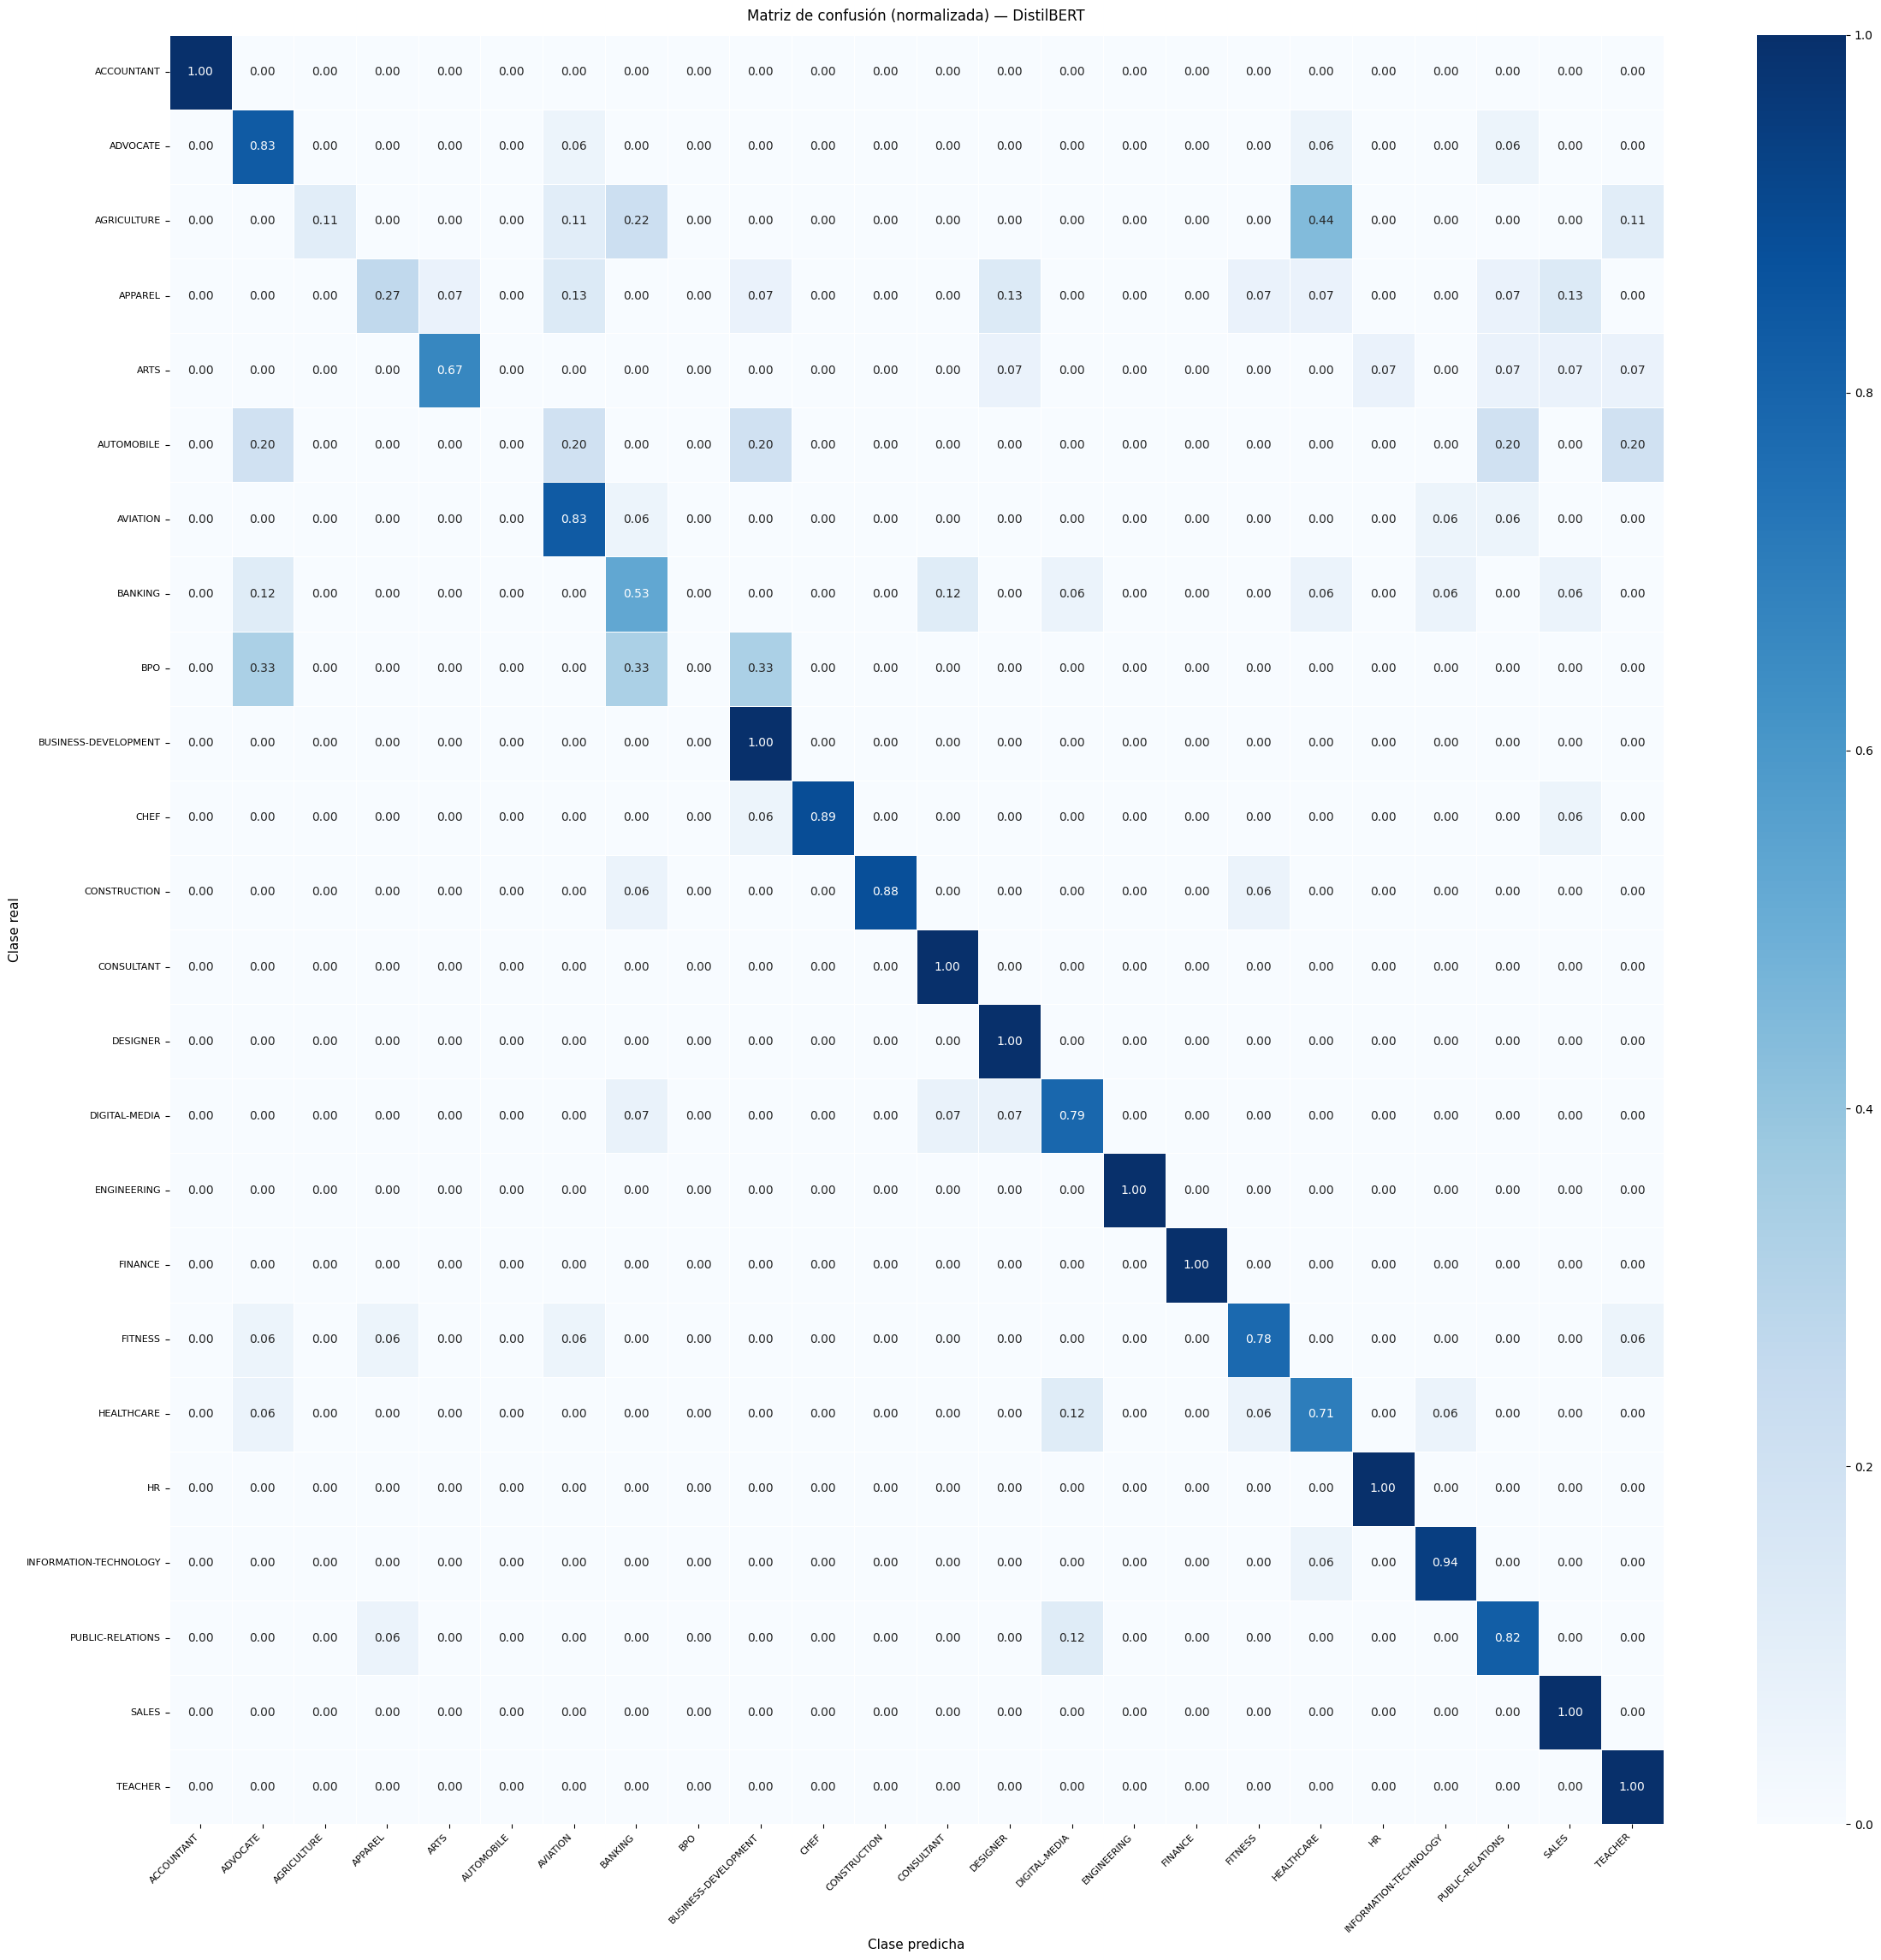

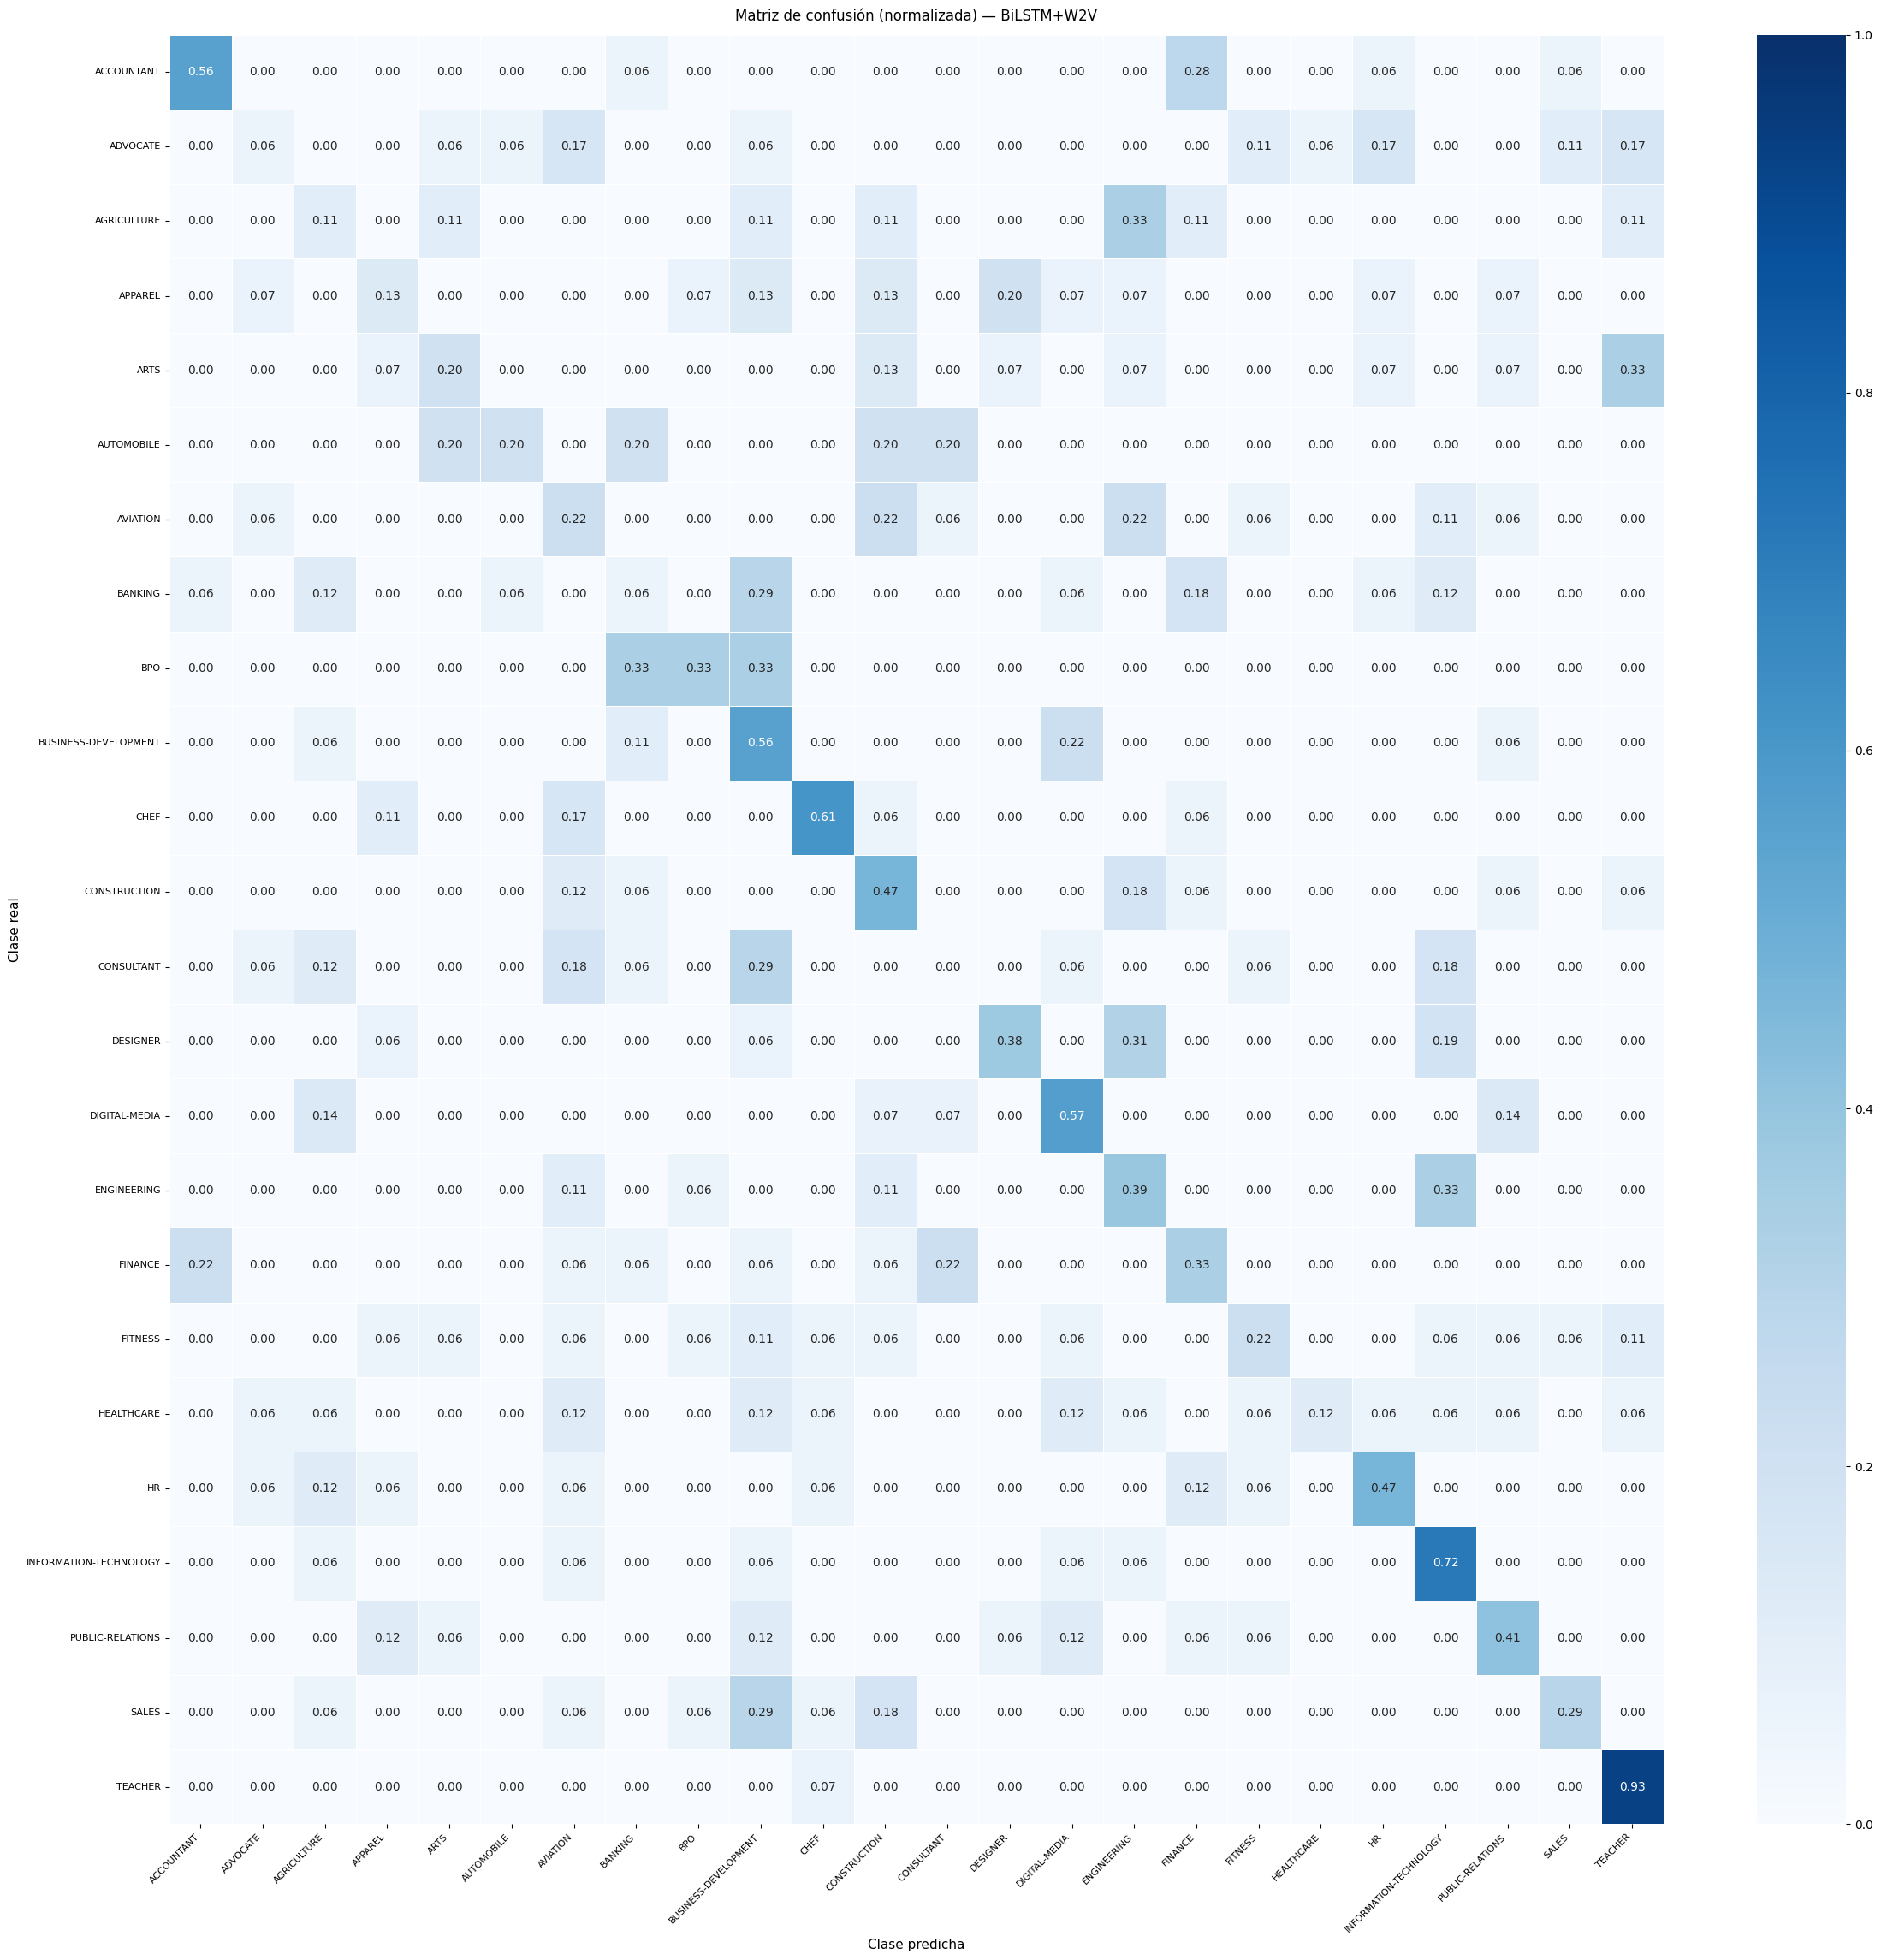

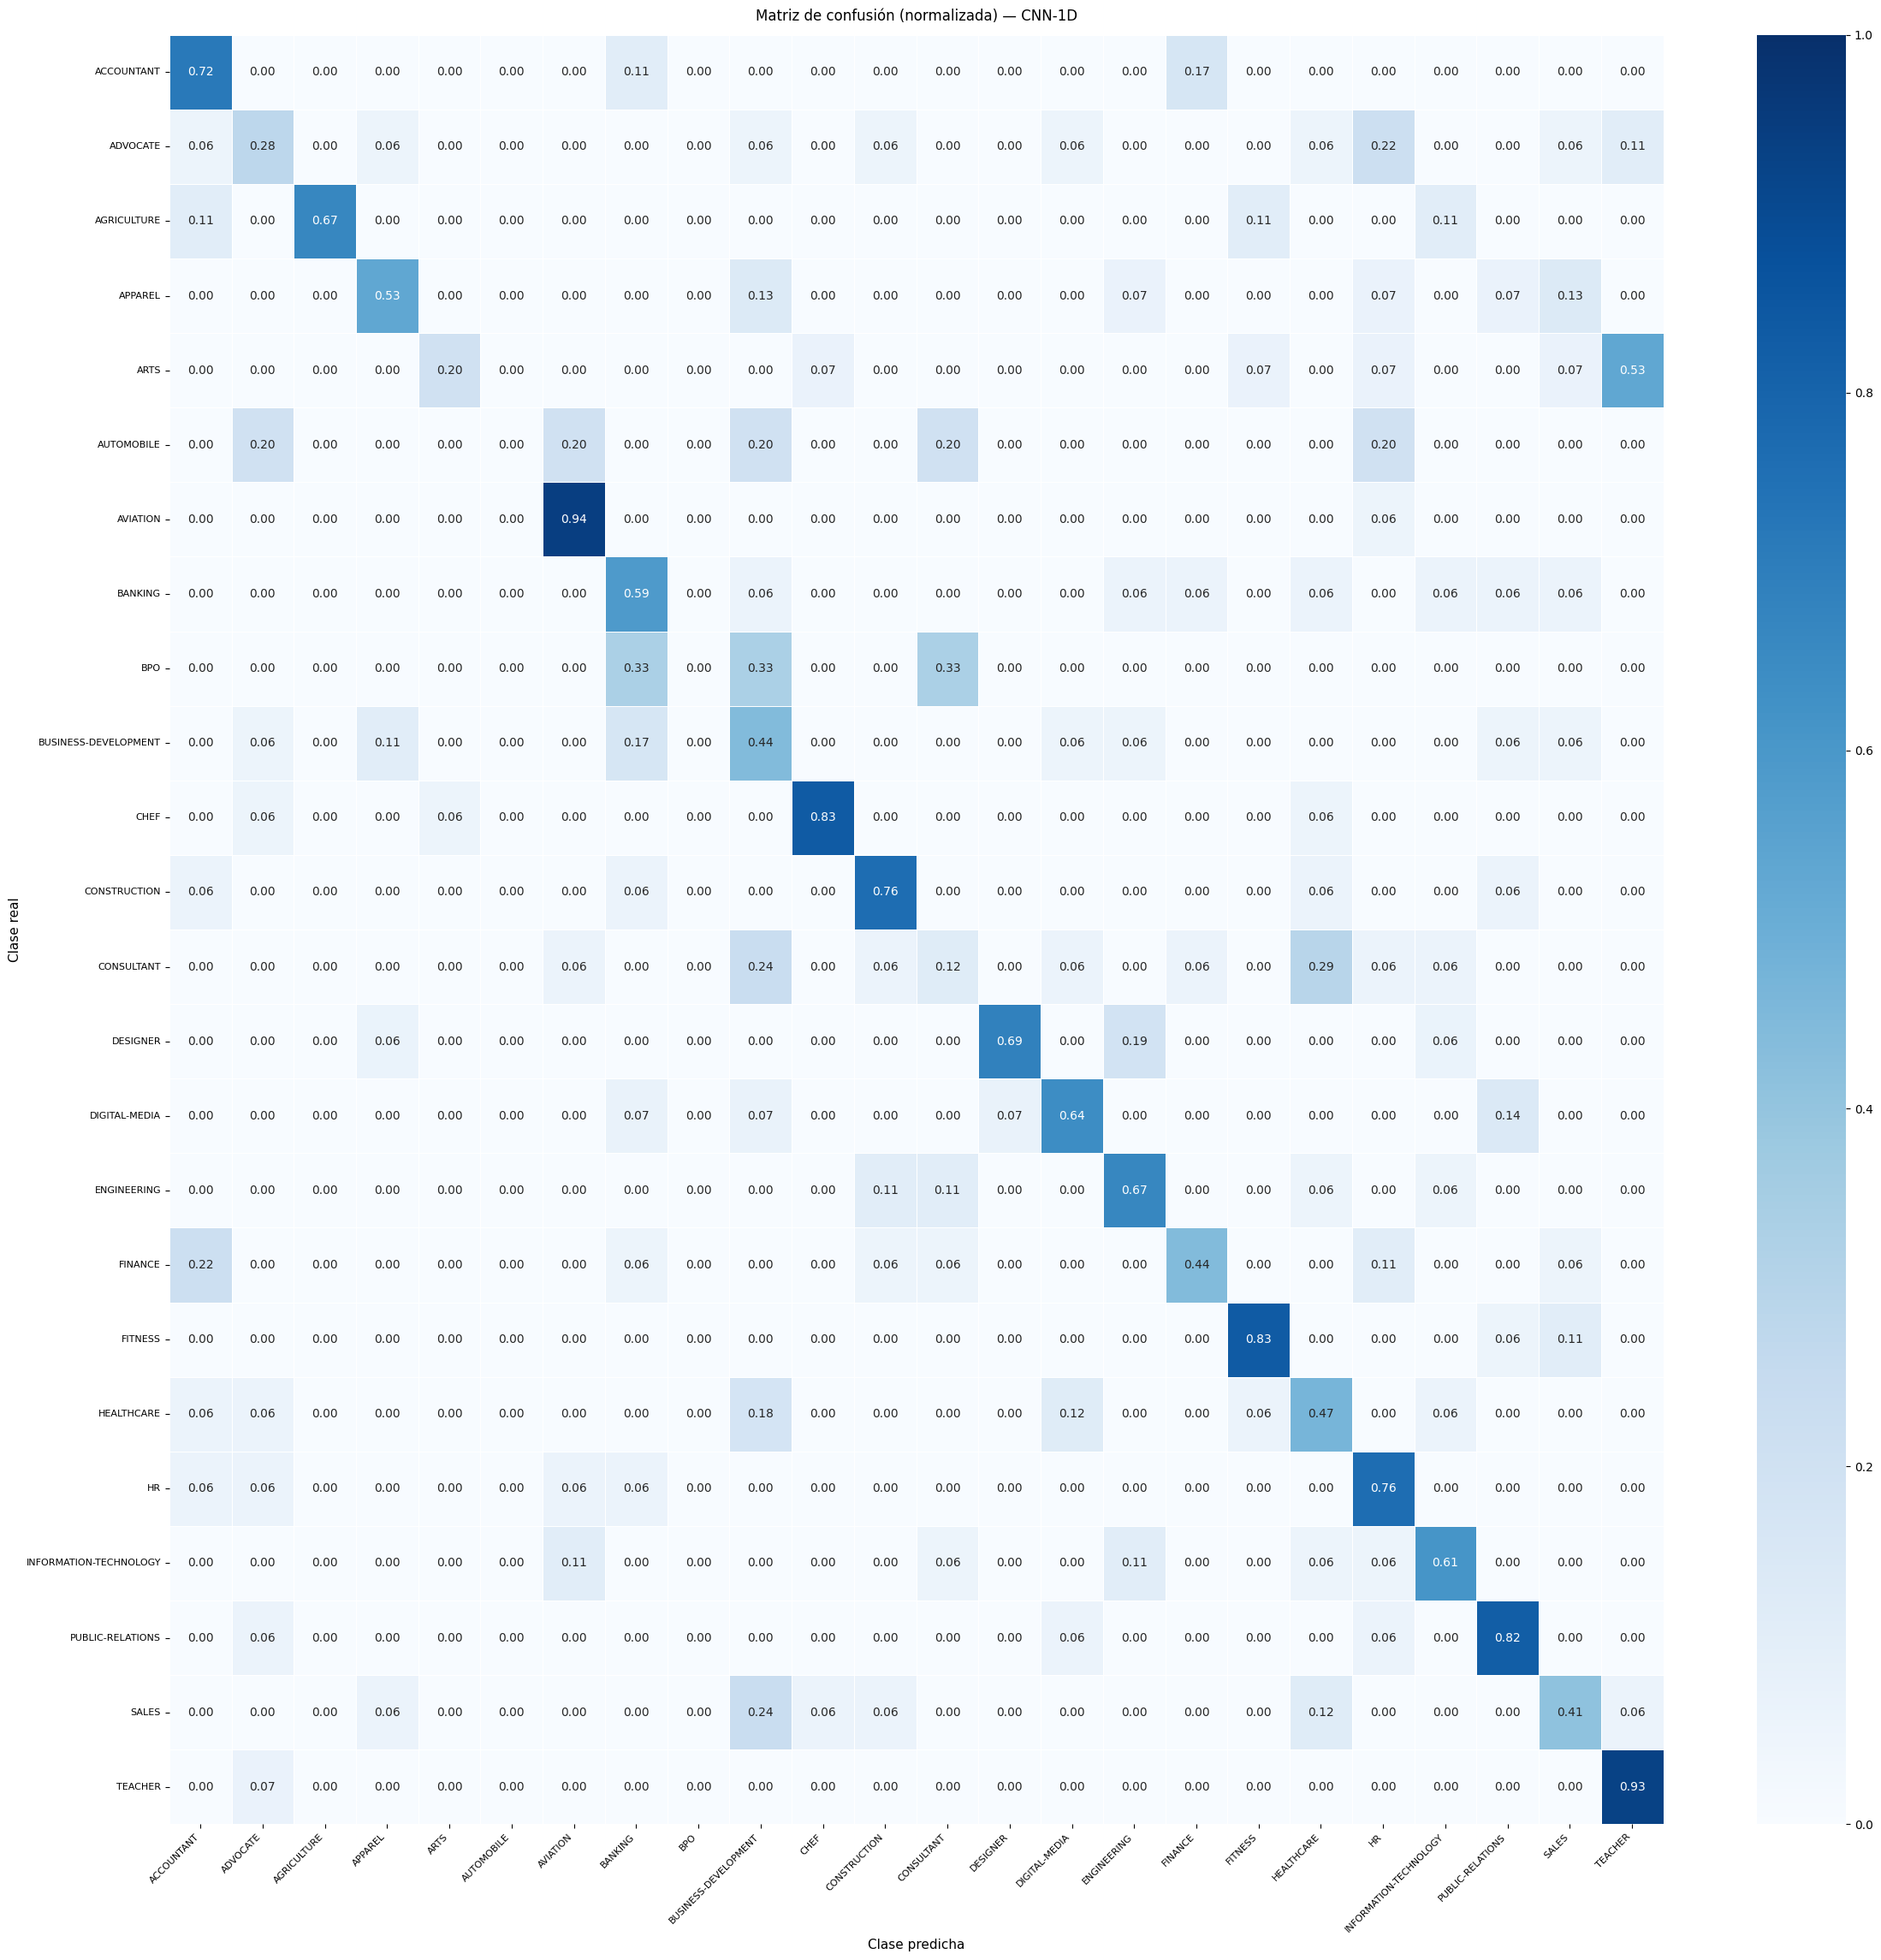

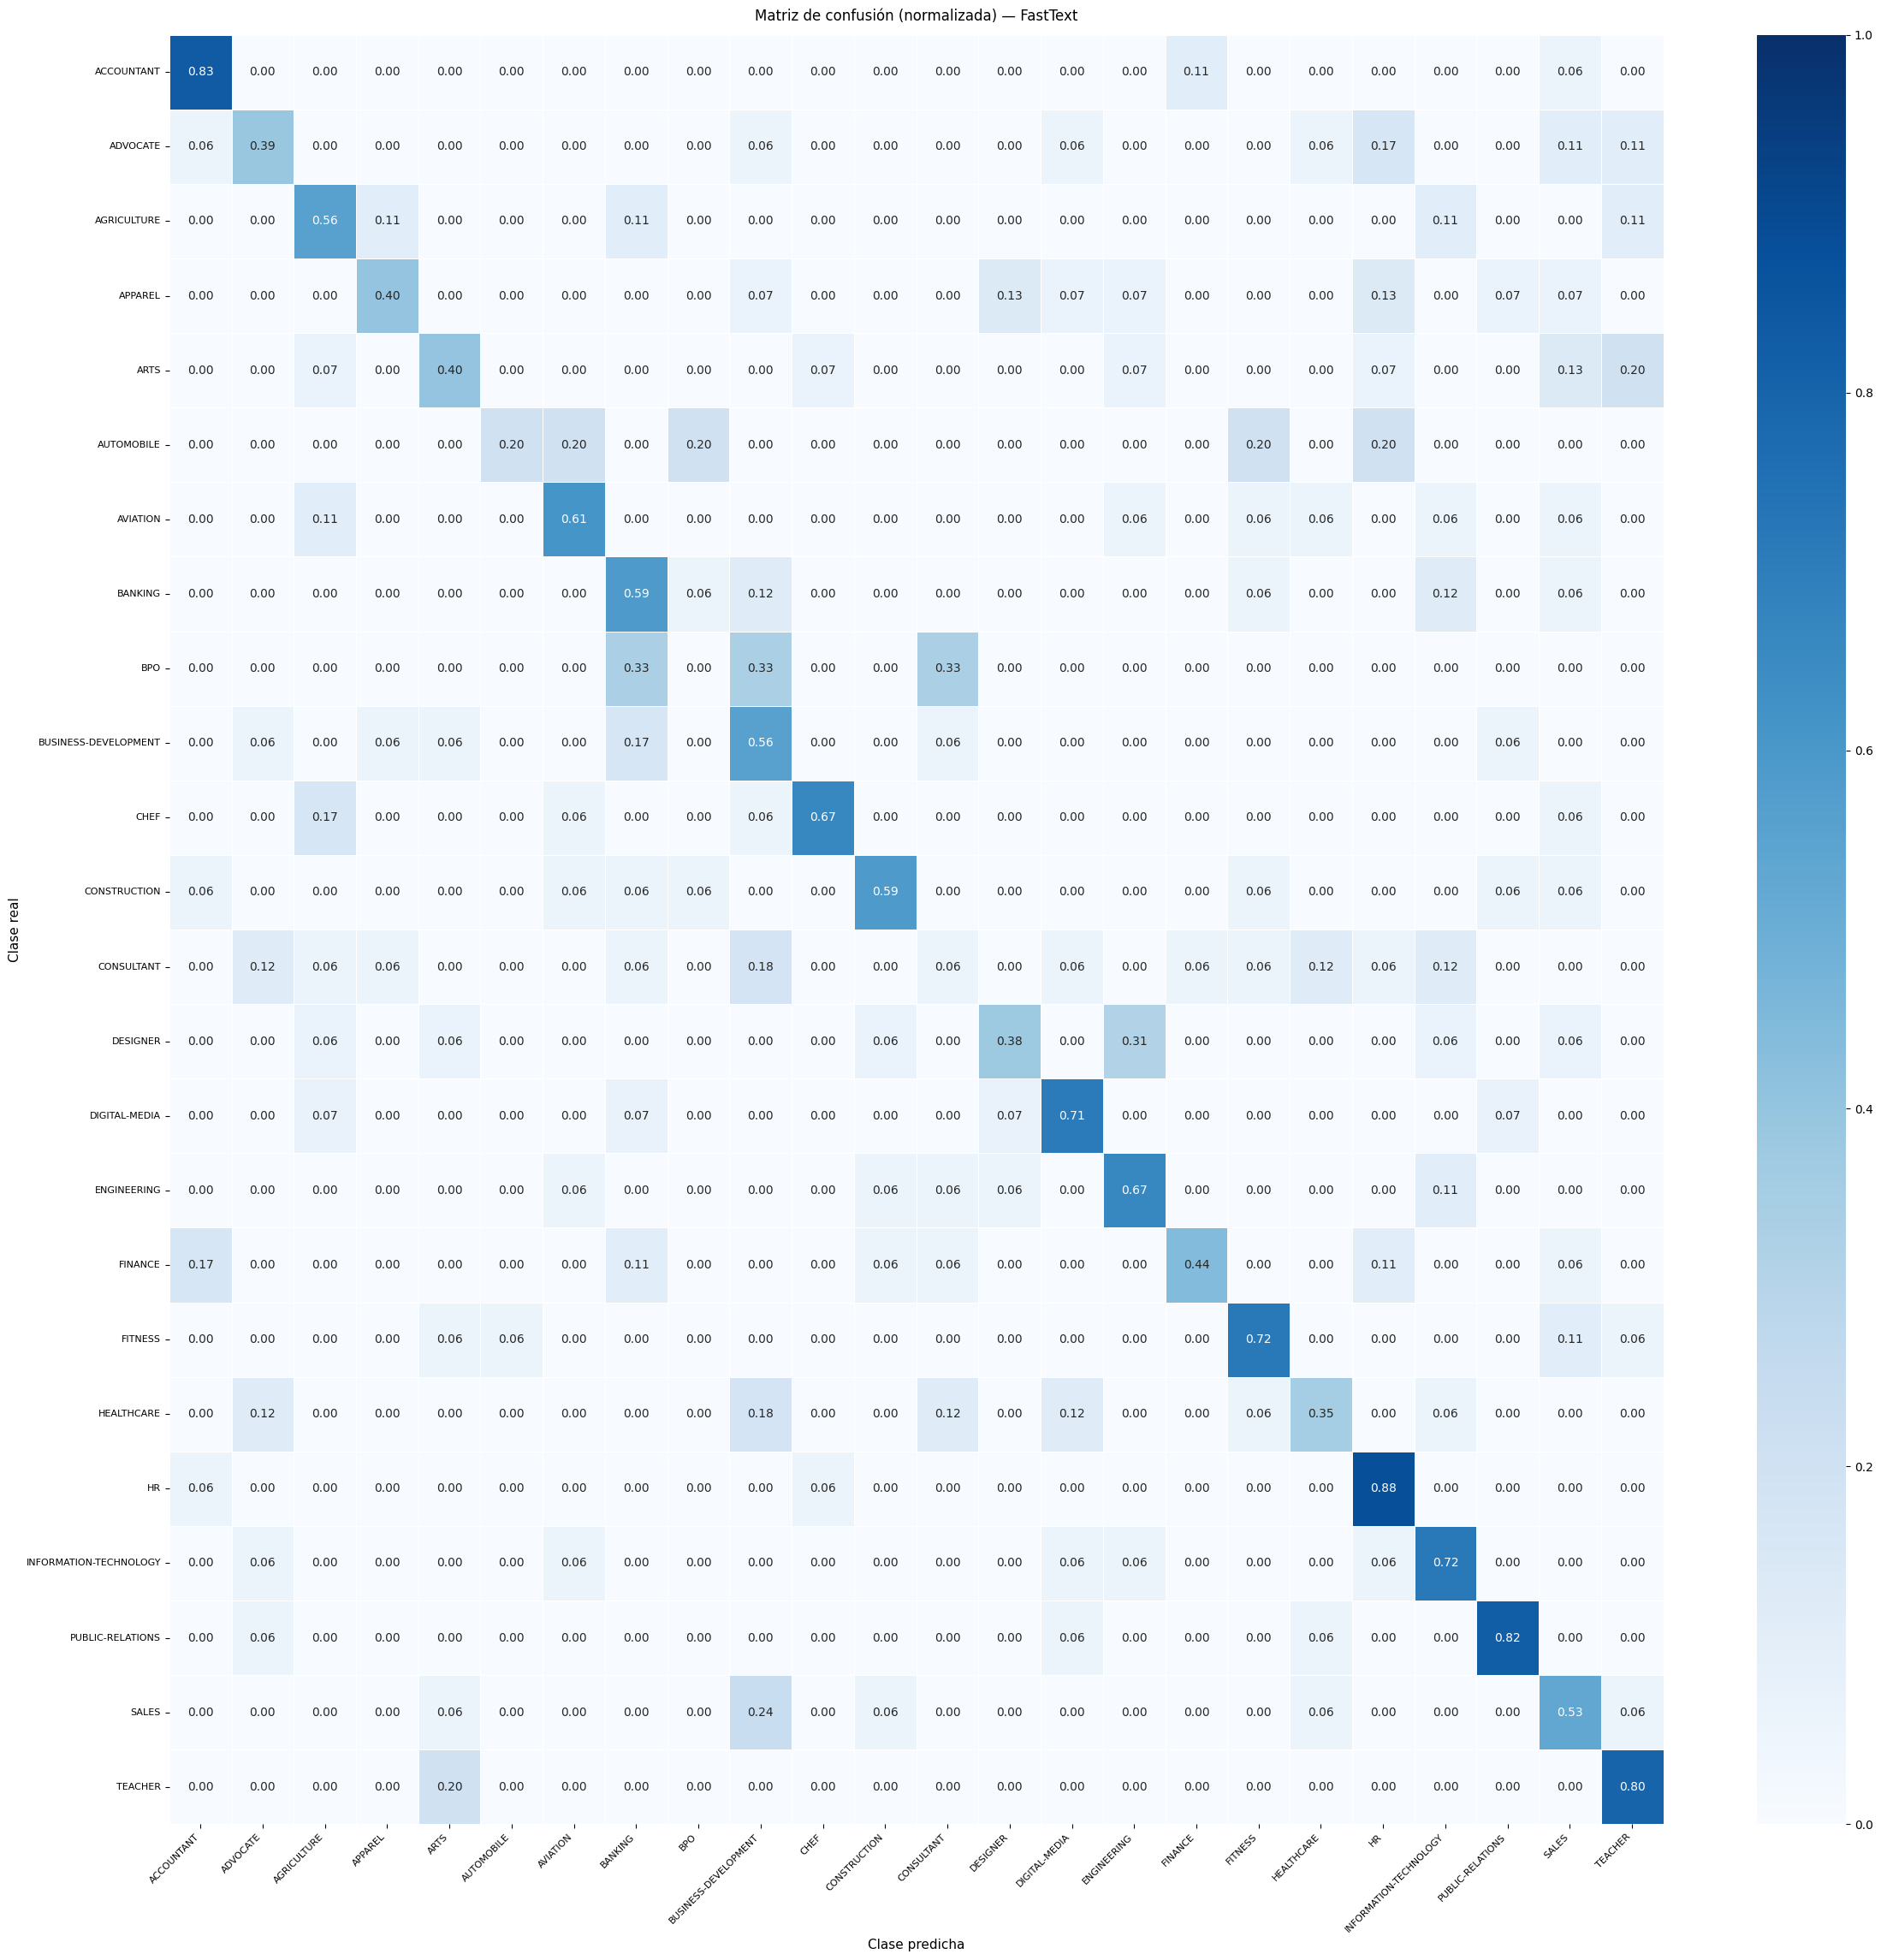

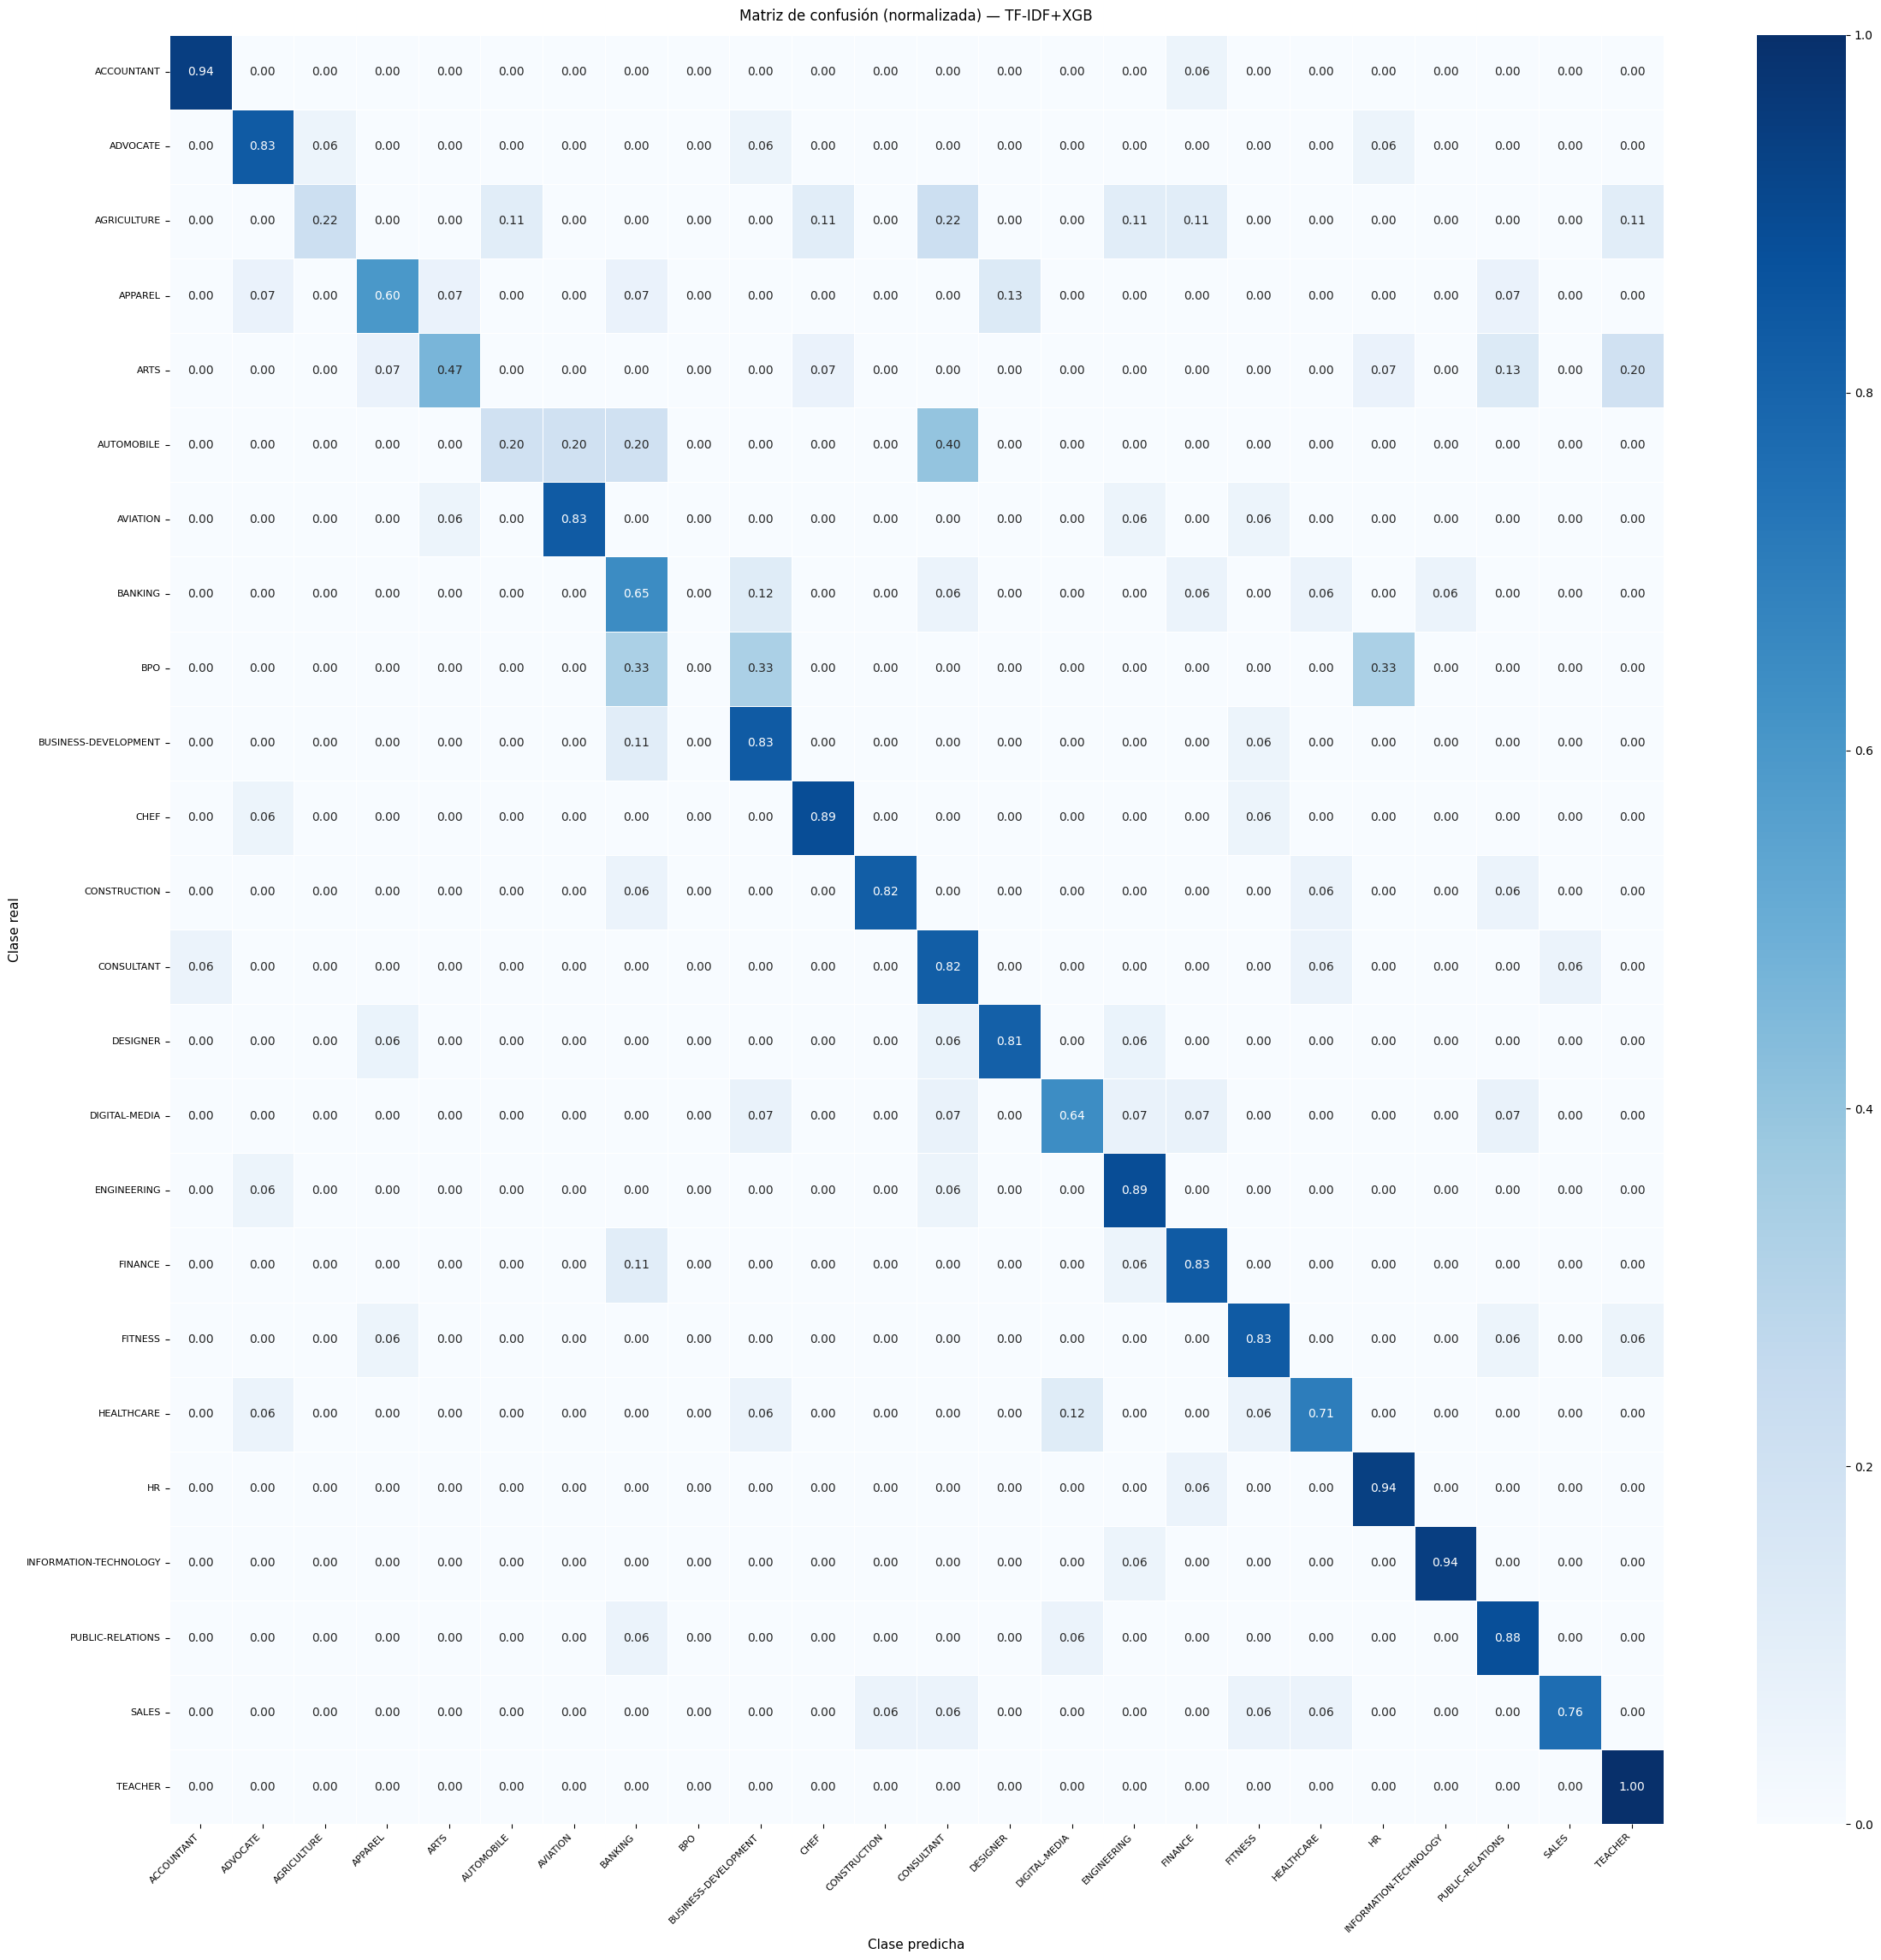

In [10]:
def plot_confusion_matrix(y_true, y_pred, model_name, class_names=CLASS_NAMES):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    n  = len(class_names)
    fig, ax = plt.subplots(figsize=(max(6, n), max(5, n - 1)))

    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.4, vmin=0, vmax=1, ax=ax,
    )
    ax.set_xlabel("Clase predicha", fontsize=11)
    ax.set_ylabel("Clase real",     fontsize=11)
    ax.set_title(f"Matriz de confusión (normalizada) — {model_name}", fontsize=12, pad=12)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0,  fontsize=8)
    plt.tight_layout()
    slug = model_name.lower().replace(" ", "_").replace("+", "plus")
    fig.savefig(f"figures/cm_{slug}.png", dpi=150)
    plt.show()
    logger.info("Matriz de confusión guardada para %s.", model_name)


for name, y_pred in [
    ("DistilBERT", pred_tf),
    ("BiLSTM+W2V", pred_bi),
    ("CNN-1D",     pred_cnn),
    ("FastText",   pred_ft),
    ("TF-IDF+XGB", pred_xgb),
]:
    plot_confusion_matrix(y_test, y_pred, name)


---
## 5.6 Curvas ROC (One-vs-Rest, macro-average)

La **curva ROC** grafica la tasa de verdaderos positivos (TPR) frente a la
tasa de falsos positivos (FPR) al variar el umbral de decisión.

- Un clasificador perfecto tiene AUC = 1.0; uno aleatorio, AUC = 0.5.
- **Para clasificación multiclase se usa la estrategia **One-vs-Rest**:
  se entrena una curva por clase (líneas semitransparentes) y se promedia
  sobre todas ellas (línea gruesa = macro-avg).**
- El promedio macro trata a todas las clases por igual, lo que es sensible
  a dificultades en clases minoritarias que el promedio ponderado suavizaría.


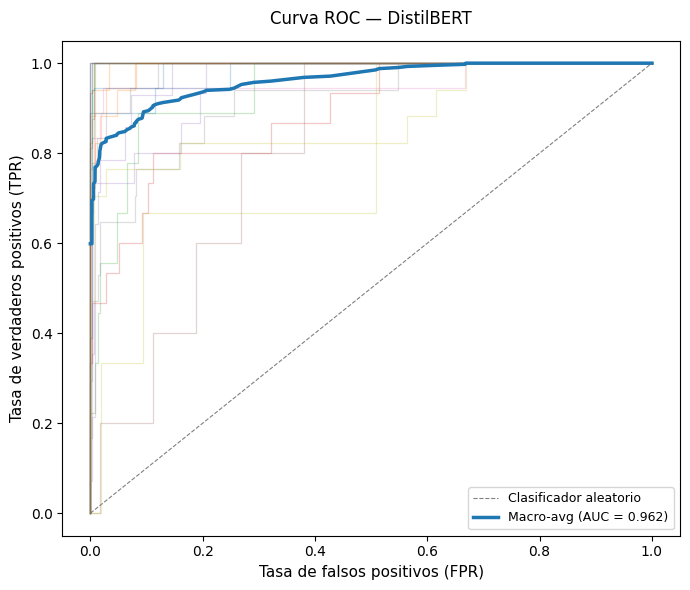

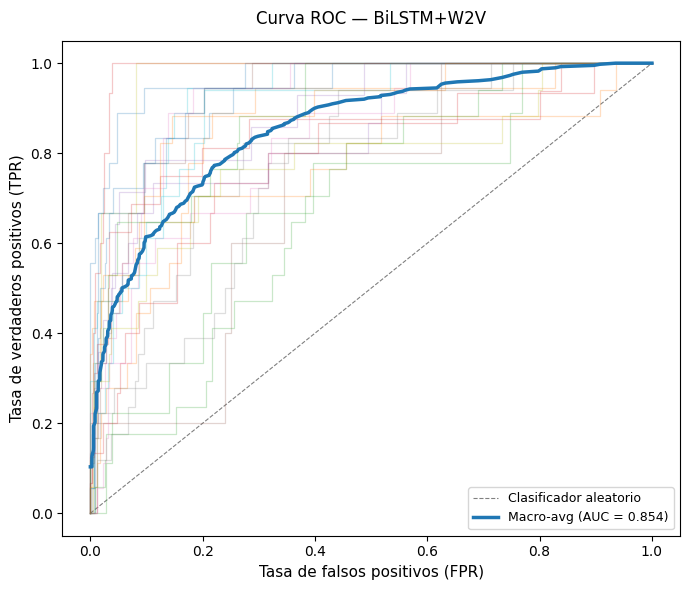

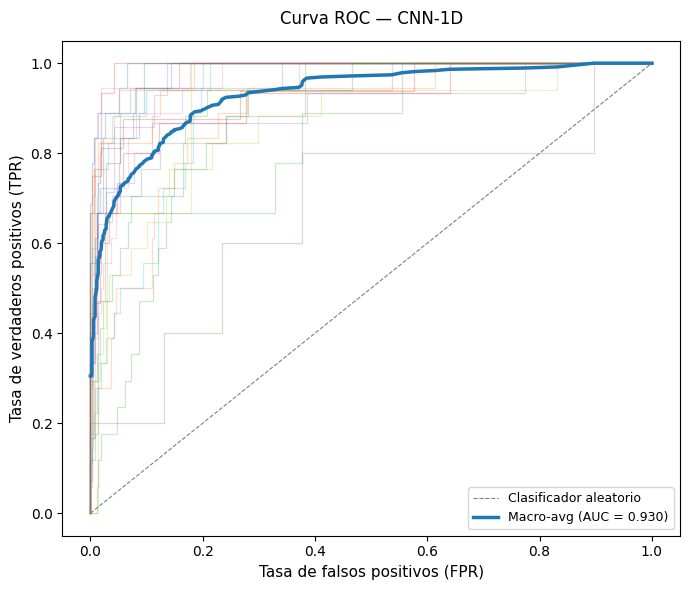

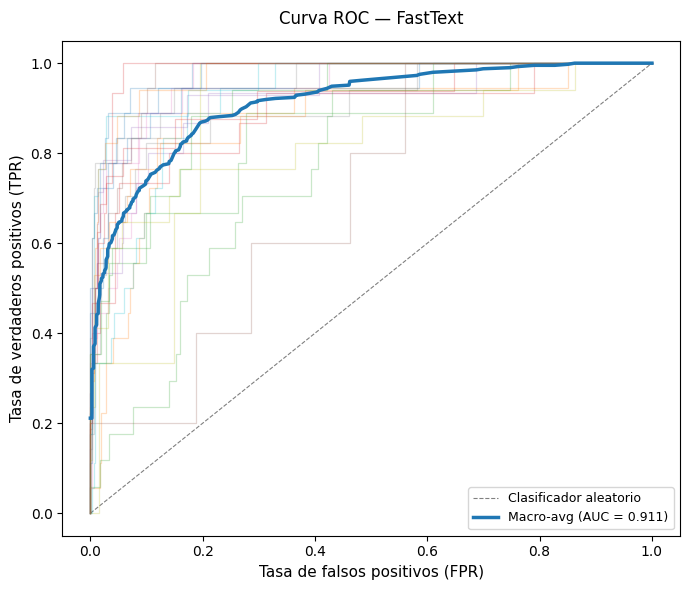

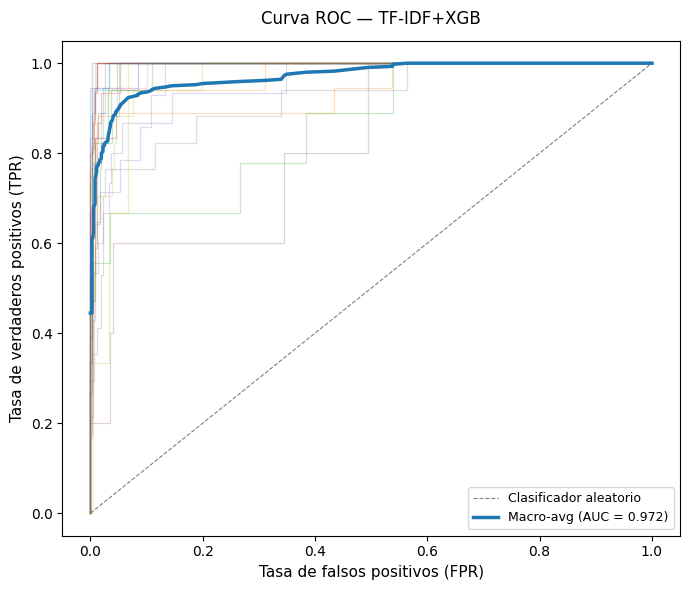

In [11]:
def plot_roc_curve(y_true, y_proba, model_name, class_names=CLASS_NAMES):
    n_cls = len(class_names)
    y_bin = label_binarize(y_true, classes=list(range(n_cls)))

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=0.8, label="Clasificador aleatorio")

    # Curvas por clase (semitransparentes para no saturar el gráfico)
    for i in range(n_cls):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        ax.plot(fpr_i, tpr_i, alpha=0.25, linewidth=0.9)

    # Macro-average interpolada sobre una rejilla común de FPR
    all_fpr = np.unique(np.concatenate([
        roc_curve(y_bin[:, i], y_proba[:, i])[0] for i in range(n_cls)
    ]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_cls):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= n_cls
    macro_auc = auc(all_fpr, mean_tpr)

    ax.plot(all_fpr, mean_tpr, linewidth=2.5,
            label=f"Macro-avg (AUC = {macro_auc:.3f})", color="#1f77b4")
    ax.set_xlabel("Tasa de falsos positivos (FPR)", fontsize=11)
    ax.set_ylabel("Tasa de verdaderos positivos (TPR)", fontsize=11)
    ax.set_title(f"Curva ROC — {model_name}", fontsize=12, pad=12)
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    slug = model_name.lower().replace(" ", "_").replace("+", "plus")
    fig.savefig(f"figures/roc_{slug}.png", dpi=150)
    plt.show()
    logger.info("Curva ROC guardada para %s (AUC=%.4f).", model_name, macro_auc)


for name, proba in [
    ("DistilBERT", proba_tf),
    ("BiLSTM+W2V", proba_bi),
    ("CNN-1D",     proba_cnn),
    ("FastText",   proba_ft),
    ("TF-IDF+XGB", proba_xgb),
]:
    plot_roc_curve(y_test, proba, name)


---
## 5.7 Curvas Precision-Recall (macro-average)

Las **curvas Precision-Recall** son especialmente informativas cuando el
dataset tiene clases desbalanceadas, porque el eje de False Positive Rate (FPR) en las curvas ROC
puede enmascarar un alto número de falsos positivos en clases minoritarias.

> La caída abrupta de precisión al aumentar el recall revela las clases donde
> el modelo "sacrifica" exactitud para no perderse instancias positivas.


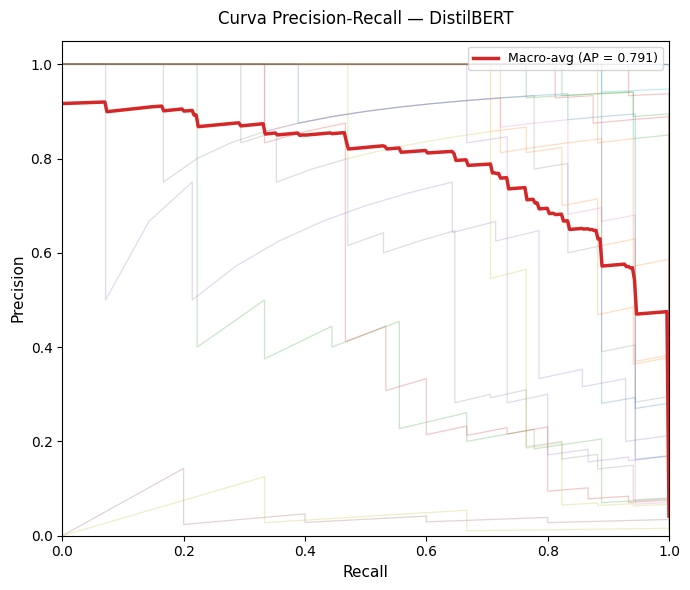

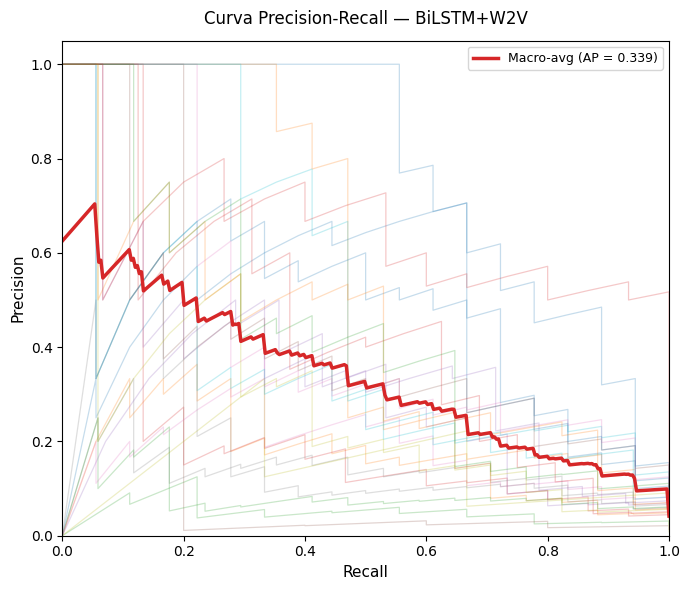

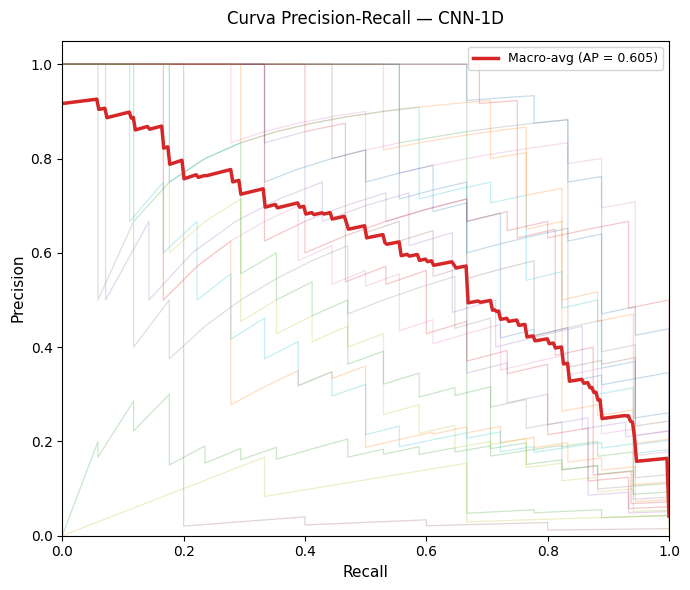

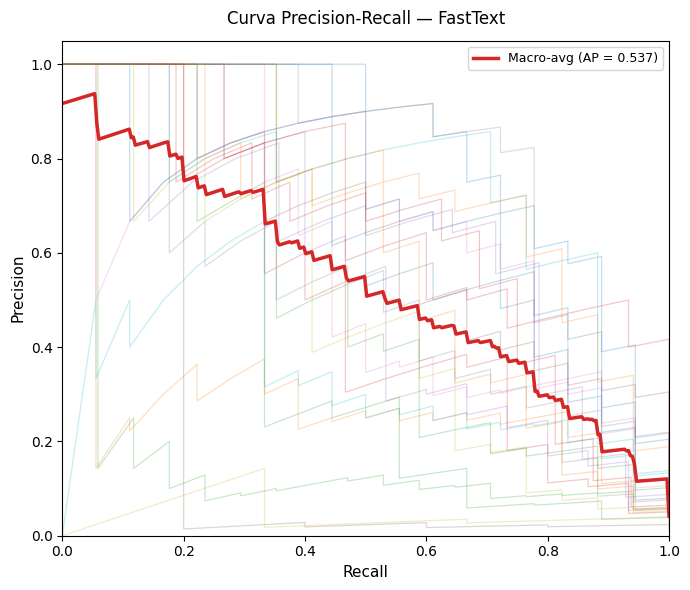

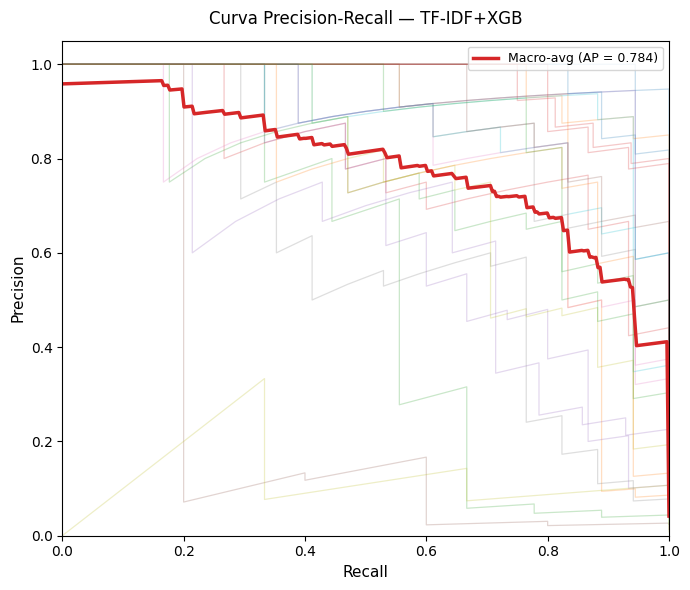

In [12]:
def plot_precision_recall(y_true, y_proba, model_name, class_names=CLASS_NAMES):
    n_cls = len(class_names)
    y_bin = label_binarize(y_true, classes=list(range(n_cls)))

    fig, ax = plt.subplots(figsize=(7, 6))
    recall_grid = np.linspace(0, 1, 300)
    mean_prec   = np.zeros_like(recall_grid)

    for i in range(n_cls):
        p_i, r_i, _ = precision_recall_curve(y_bin[:, i], y_proba[:, i])
        ax.plot(r_i, p_i, alpha=0.25, linewidth=0.9)
        mean_prec += np.interp(recall_grid, np.flip(r_i), np.flip(p_i))

    mean_prec /= n_cls
    macro_ap = auc(recall_grid, mean_prec)

    ax.plot(recall_grid, mean_prec, linewidth=2.5,
            label=f"Macro-avg (AP = {macro_ap:.3f})", color="#d62728")
    ax.set_xlabel("Recall",    fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.set_title(f"Curva Precision-Recall — {model_name}", fontsize=12, pad=12)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    plt.tight_layout()
    slug = model_name.lower().replace(" ", "_").replace("+", "plus")
    fig.savefig(f"figures/pr_{slug}.png", dpi=150)
    plt.show()
    logger.info("Curva PR guardada para %s (AP=%.4f).", model_name, macro_ap)


for name, proba in [
    ("DistilBERT", proba_tf),
    ("BiLSTM+W2V", proba_bi),
    ("CNN-1D",     proba_cnn),
    ("FastText",   proba_ft),
    ("TF-IDF+XGB", proba_xgb),
]:
    plot_precision_recall(y_test, proba, name)


## Tabla final comparativa

<!-- ---
## 5.8 Tabla consolidada comparativa -->


  COMPARACIÓN DE MODELOS — TEST SET
           Accuracy Precision   Recall F1-score  ROC-AUC
Modelo                                                  
DistilBERT  82.31 %   81.24 %  82.31 %  80.11 %  96.05 %
TF-IDF+XGB  78.28 %   78.18 %  78.28 %   77.3 %  97.04 %
CNN-1D      59.52 %   59.27 %  59.52 %   57.8 %  92.87 %
FastText    56.84 %   57.15 %  56.84 %  55.71 %  90.97 %
BiLSTM+W2V  35.66 %   36.57 %  35.66 %  33.58 %  85.25 %



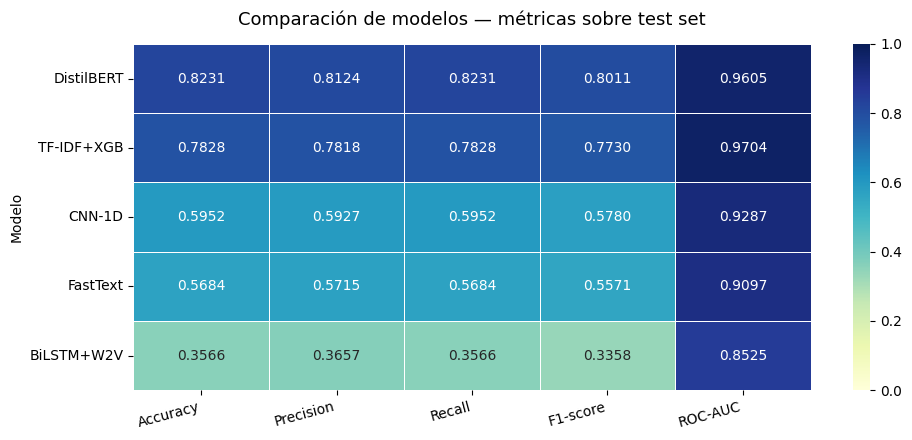

In [13]:
def build_comparison_table(metrics_list):
    df = pd.DataFrame(metrics_list).set_index("Modelo")
    df = df.sort_values("F1-score", ascending=False)

    # ── Impresión tabular ─────────────────────────────────────────────────────
    print("\n" + "=" * 66)
    print("  COMPARACIÓN DE MODELOS — TEST SET")
    print("=" * 66)
    display_df = (df * 100).round(2).astype(str) + " %"
    print(display_df.to_string())
    print("=" * 66 + "\n")

    # ── Heatmap ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, max(3, len(df) * 0.7 + 1)))
    sns.heatmap(
        df.astype(float),
        annot=True, fmt=".4f", cmap="YlGnBu",
        vmin=0, vmax=1, linewidths=0.5,
        annot_kws={"size": 10}, ax=ax,
    )
    ax.set_title("Comparación de modelos — métricas sobre test set",
                 fontsize=13, pad=14)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=10)
    plt.tight_layout()
    fig.savefig("figures/model_comparison_heatmap.png", dpi=150)
    plt.show()

    return df


comparison_df = build_comparison_table(all_metrics)

# Exportar para referencias externas (informes, slides)
comparison_df.to_csv("figures/model_comparison.csv")
logger.info("Tabla comparativa exportada a figures/model_comparison.csv")


---

## 5.11 Análisis de Resultados y Conclusiones del Experimento

Los resultados que se presentan a continuación se derivan de la evaluación ciega
sobre el conjunto de Test (373 muestras, 24 clases profesionales), utilizando
modelos entrenados sobre 1.737 muestras sin ningún contacto previo con este subconjunto.

### Tabla de referencia consolidada

| Modelo | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---|---|---|---|---|
| **DistilBERT** | **82.31 %** | **81.24 %** | **82.31 %** | **80.11 %** | 96.05 % |
| TF-IDF + XGB | 78.28 % | 78.18 % | 78.28 % | 77.30 % | **97.04 %** |
| CNN-1D | 59.52 % | 59.27 % | 59.52 % | 57.80 % | 92.87 % |
| FastText | 56.84 % | 57.15 % | 56.84 % | 55.71 % | 90.97 % |
| BiLSTM + W2V | 35.66 % | 36.57 % | 35.66 % | 33.58 % | 85.25 % |

---

### Pregunta 1 — ¿Qué arquitectura domina en el trade-off Precision–Recall?

**DistilBERT domina ambas dimensiones simultáneamente**, pero el análisis detallado
revela matices que no son visibles en la tabla de métricas escalares.

**Brecha Precision–Recall por modelo:**

| Modelo | Precision | Recall | Brecha (R − P) | Interpretación |
|---|---|---|---|---|
| DistilBERT | 81.24 % | 82.31 % | **+1.07 pp** | Ligero sesgo a no perder positivos verdaderos |
| TF-IDF + XGB | 78.18 % | 78.28 % | +0.10 pp | Prácticamente balanceado |
| CNN-1D | 59.27 % | 59.52 % | +0.25 pp | Balanceado |
| FastText | 57.15 % | 56.84 % | −0.31 pp | Ligero sesgo hacia precisión |
| BiLSTM + W2V | 36.57 % | 35.66 % | **−0.91 pp** | El modelo "se abstiene" más de lo que confunde |

DistilBERT es el único modelo que supera el 80 % en ambos ejes simultáneamente,
lo que en una tarea de 24 clases con ~72 muestras por clase en promedio es un
resultado sólido. Sin embargo, hay un dato que rompe la intuición inicial:
**TF-IDF + XGBoost obtiene el ROC-AUC más alto del experimento (97.04 %),
superando incluso al transformer (96.05 %)**.

Esto no es contradictorio, sino que refleja una distinción conceptual importante:
el **F1-score** evalúa la calidad de las predicciones duras (el argmax de los
logits), mientras que el **ROC-AUC** evalúa la calibración de las probabilidades
a lo largo de todos los umbrales posibles bajo la estrategia One-vs-Rest.
XGBoost produce distribuciones de probabilidad mejor separadas entre clases, pero
su umbral de decisión por defecto genera más errores de clasificación final que
DistilBERT. En un entorno de producción, esto implica que un clasificador basado
en XGBoost podría aproximarse al rendimiento del transformer si se optimizan los
umbrales de decisión por clase en lugar de aplicarse el argmax directo.

---

### Pregunta 2 — ¿Cuánto mejora el transfer learning (DistilBERT) sobre las líneas base?

La ganancia varía radicalmente según qué se considere "línea base":

- **Sobre TF-IDF + XGBoost** (baseline clásico optimizado):
  - Accuracy: +4.03 pp | F1-score: **+2.81 pp** | ROC-AUC: −0.99 pp *(XGBoost es superior en discriminación probabilística)*
- **Sobre CNN-1D** (baseline de Deep Learning ligero):
  - Accuracy: +22.79 pp | F1-score: **+22.31 pp**
- **Sobre BiLSTM + W2V** (arquitectura recurrente más compleja):
  - Accuracy: +46.65 pp | F1-score: **+46.53 pp**

El resultado más relevante del experimento no es la ganancia de DistilBERT, sino
el **colapso del BiLSTM** (F1 = 33.58 %), que incluso queda por debajo del
clasificador FastText más simple (55.71 %). Con 1.737 muestras de entrenamiento
repartidas entre 24 clases —un promedio de 72 muestras por clase— la BiLSTM no
dispone de suficiente señal para aprender dependencias de largo alcance de forma
confiable. A esto se suma que los embeddings Word2Vec entrenados sobre ese mismo
corpus reducido tienen calidad y cobertura limitadas, deteriorando la representación
desde la primera capa del modelo.

La CNN-1D, en cambio, sobrevive mejor a la escasez de datos porque los patrones
locales que detectan sus kernels —bigramas y trigramas de términos técnicos como
*machine learning*, *data analysis* o *project management*— son altamente
discriminativos para clasificar CVs sin necesidad de modelar dependencias de largo
alcance. Esto ilustra un principio general: **una arquitectura más compleja no
garantiza mejor generalización cuando el volumen de datos de entrenamiento no es
suficiente para amortizar su capacidad paramétrica**.

---

### Pregunta 3 — ¿Justifica la complejidad del transformer la ganancia sobre la CNN-1D?


- **Desde el punto de vista del rendimiento puro:** sí. Una brecha de 22.31 pp en
  F1 (80.11 % vs 57.80 %) es sustancial en una tarea de 24 clases. En términos
  concretos, sobre el test set de 373 CVs, DistilBERT clasifica correctamente
  aproximadamente **83 documentos más** que la CNN-1D.

- **Desde el punto de vista de la relación complejidad–ganancia:** la comparación
  más incómoda no es DistilBERT vs CNN-1D, sino **DistilBERT vs TF-IDF + XGBoost**.
  El modelo clásico —sin GPU, sin embeddings neuronales, sin dependencias del
  ecosistema HuggingFace— alcanza el 77.30 % de F1, a solo **2.81 pp** del
  transformer de ~66M de parámetros. Esa brecha es modesta para la diferencia de
  complejidad que implica en términos de infraestructura, latencia de inferencia
  y coste de mantenimiento.

Lo que sí diferencia al transformer de forma clara es su **robustez de clasificación
bajo configuración de inferencia estándar**: DistilBERT es el único modelo que
supera el umbral del 80 % en F1 sin necesidad de calibrar umbrales por clase ni
de aplicar ningún post-procesamiento sobre las probabilidades de salida.

**En conslusión,** la complejidad del transformer se justifica cuando el
objetivo es maximizar la calidad de las predicciones en un problema multiclase de
alta cardinalidad con datos limitados, y cuando la infraestructura GPU está
disponible. Si el contexto impusiera restricciones de cómputo o de latencia en
inferencia, **TF-IDF + XGBoost con calibración de probabilidades sería un
competidor directo a un coste operativo considerablemente menor**, especialmente
dado que su ROC-AUC (97.04 %) supera al del propio transformer en este experimento.

---
## 5.9 Gráfico de barras comparativo por métrica


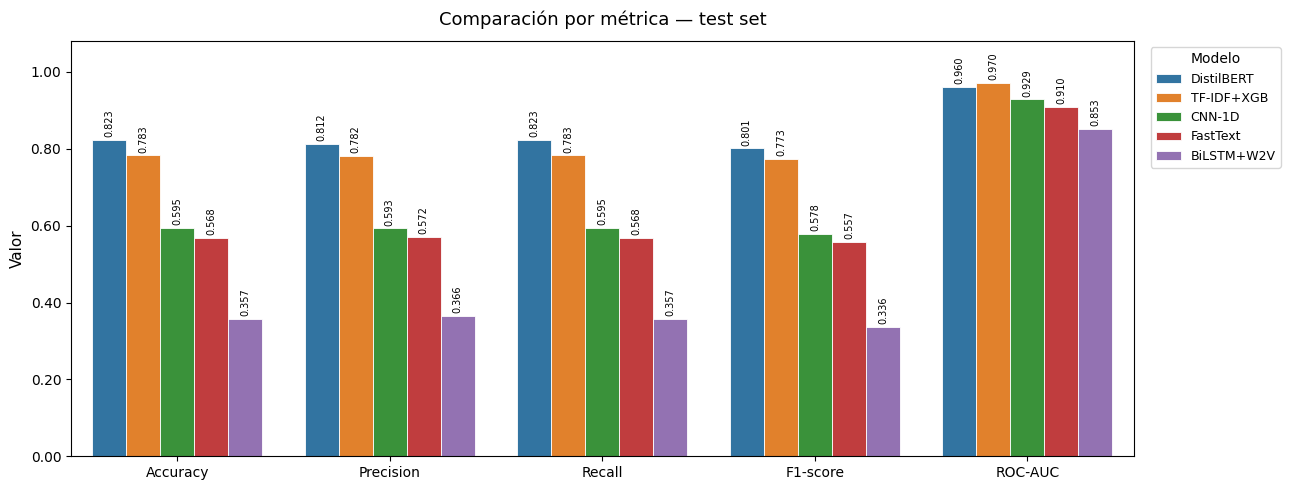

In [ ]:
metrics_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
df_plot = comparison_df[metrics_cols].reset_index()
df_melt = df_plot.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=df_melt, x="Métrica", y="Valor", hue="Modelo",
    palette="tab10", edgecolor="white", linewidth=0.6, ax=ax,
)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Valor", fontsize=11)
ax.set_xlabel("")
ax.set_title("Comparación por métrica — test set", fontsize=13, pad=12)
ax.legend(title="Modelo", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))

# Etiquetas de valor sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2, rotation=90)

plt.tight_layout()
fig.savefig("figures/model_comparison_barplot.png", dpi=150)
plt.show()
logger.info("Barplot comparativo guardado.")


---
## 5.10 Resumen ejecutivo


In [15]:
best_model   = comparison_df.index[0]
best_f1      = comparison_df.loc[best_model, "F1-score"]
best_auc     = comparison_df.loc[best_model, "ROC-AUC"]
worst_model  = comparison_df.index[-1]
worst_f1     = comparison_df.loc[worst_model, "F1-score"]
gap          = best_f1 - worst_f1

baseline_f1  = comparison_df.loc["TF-IDF+XGB", "F1-score"] if "TF-IDF+XGB" in comparison_df.index else None

print("\n" + "=" * 66)
print("  RESUMEN EJECUTIVO")
print("=" * 66)
print(
    f"\nMejor modelo     : {best_model}"
    f"\n  F1-score       : {best_f1:.4f}"
    f"\n  ROC-AUC        : {best_auc:.4f}"
    f"\n\nModelo mas debil : {worst_model}"
    f"\n  F1-score       : {worst_f1:.4f}"
    f"\n\nDiferencia absoluta entre extremos (F1): {gap:.4f}"
)
if baseline_f1 is not None:
    diff_vs_baseline = best_f1 - baseline_f1
    print(f"Ganancia del mejor modelo DL sobre TF-IDF+XGB: {diff_vs_baseline:+.4f}")

print("=" * 66)
print("\nArtefactos generados en figures/:")
for p in sorted(Path("figures").glob("*.png")):
    print(f"  {p.name}")



  RESUMEN EJECUTIVO

Mejor modelo     : DistilBERT
  F1-score       : 0.8011
  ROC-AUC        : 0.9605

Modelo mas debil : BiLSTM+W2V
  F1-score       : 0.3358

Diferencia absoluta entre extremos (F1): 0.4653
Ganancia del mejor modelo DL sobre TF-IDF+XGB: +0.0281

Artefactos generados en figures/:
  class_distribution.png
  cm_bilstmplusw2v.png
  cm_cnn-1d.png
  cm_distilbert.png
  cm_fasttext.png
  cm_tf-idfplusxgb.png
  learning_curves.png
  model_comparison_barplot.png
  model_comparison_heatmap.png
  ngrams.png
  pr_bilstmplusw2v.png
  pr_cnn-1d.png
  pr_distilbert.png
  pr_fasttext.png
  pr_tf-idfplusxgb.png
  roc_bilstmplusw2v.png
  roc_cnn-1d.png
  roc_distilbert.png
  roc_fasttext.png
  roc_tf-idfplusxgb.png
  text_length_analysis.png
  word_frequency.png
